## Caracterizar los rCMBs del estudio de ADNI a partir de las coordenadas de los centroides

In [2]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from skimage.segmentation import flood
import matplotlib.pyplot as plt

In [3]:
# --- CONFIGURACIÓN ---
BASE_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset"
IMG_DIR = os.path.join(BASE_PATH, "raw/positives")
SEG_DIR = os.path.join(BASE_PATH, "synthseg_segmentations")
CSV_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/ADNI_original_dataset_downloaded/MAYOADIRL_MRI_MCH_12Feb2026.csv"


[1] ID: I957748 - Radios calculados con v10.


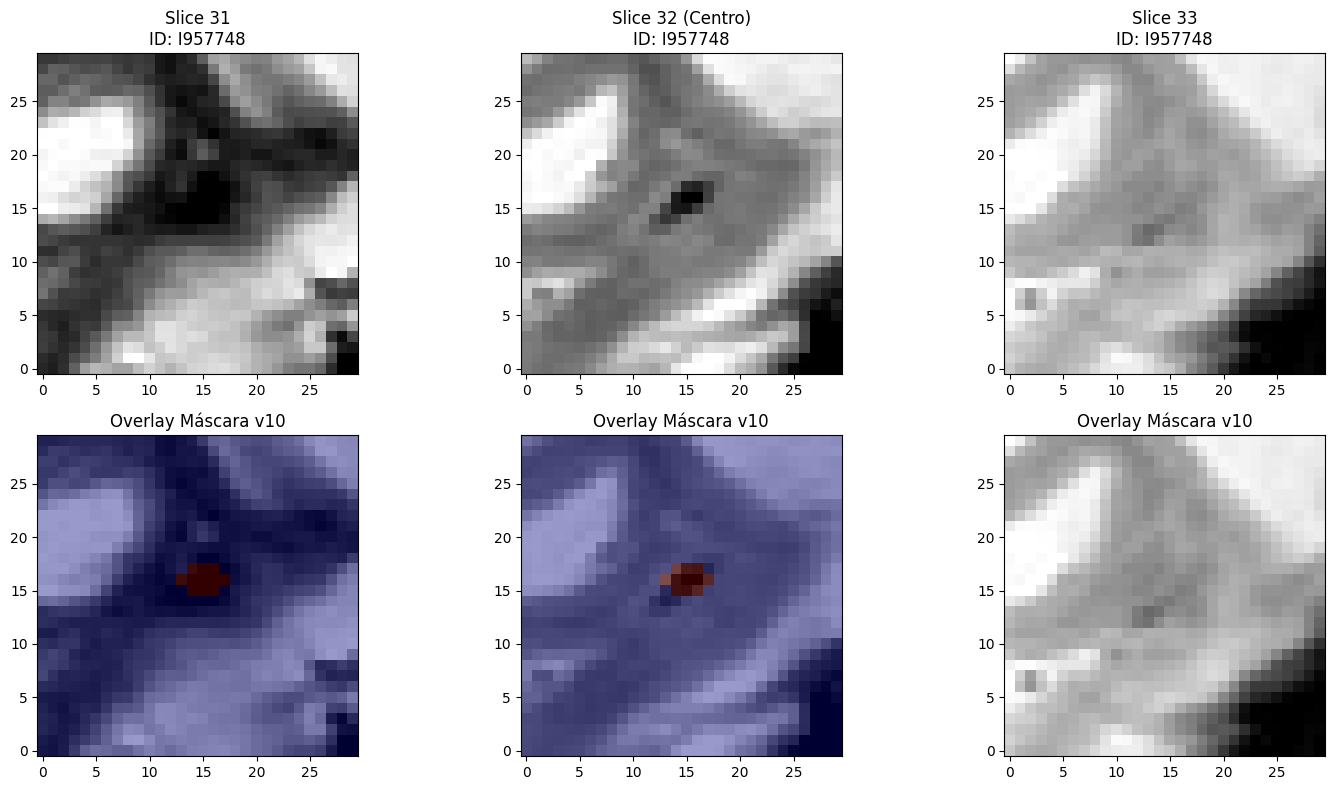

[2] ID: I987397 - Radios calculados con v10.


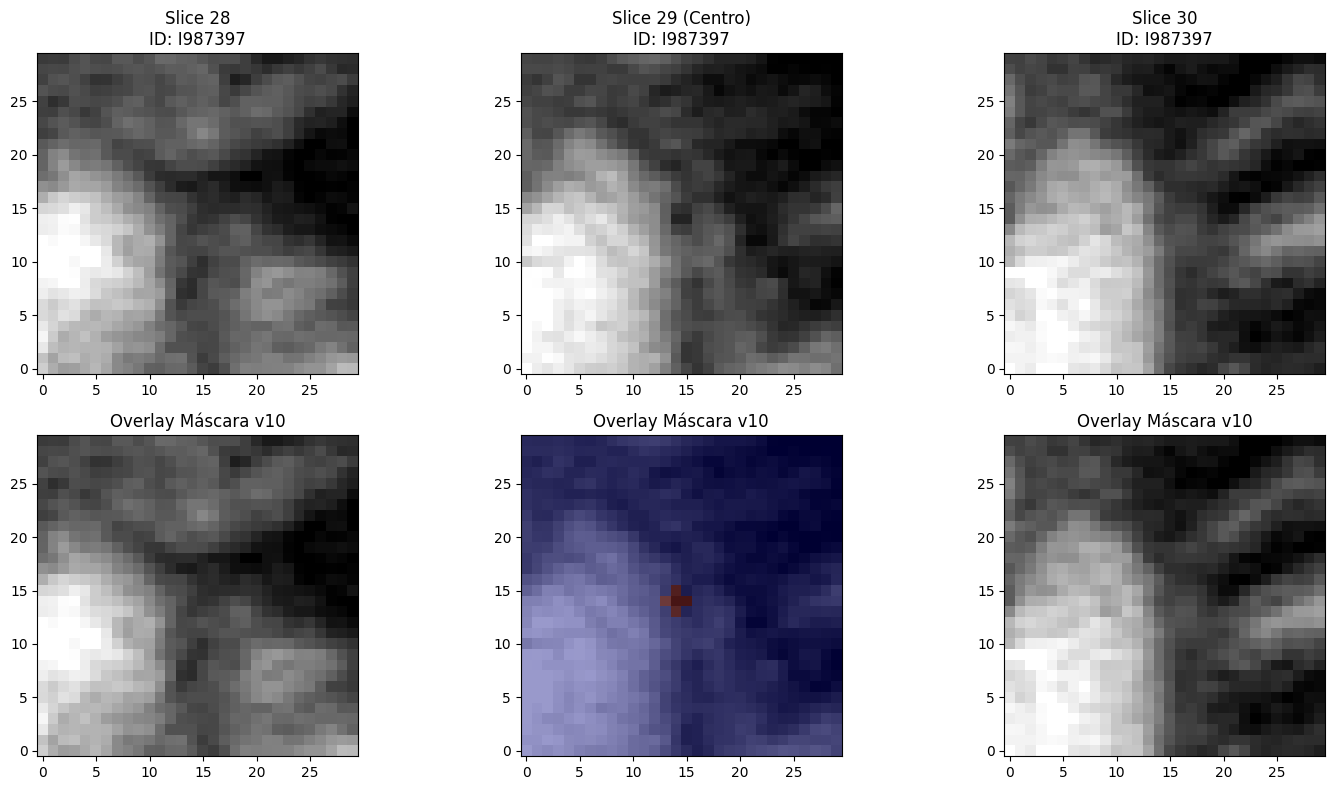

[3] ID: I1158141 - Radios calculados con v10.


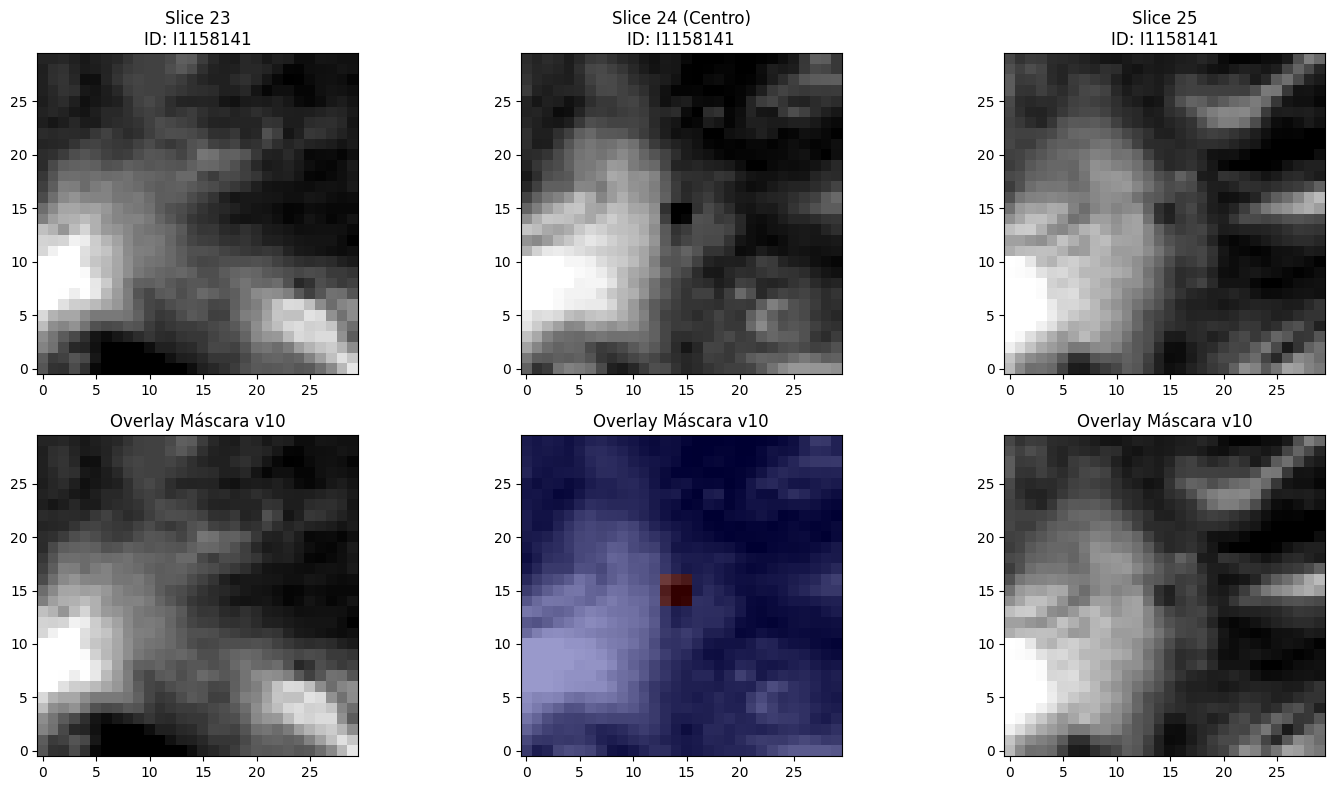

[4] ID: I1158141 - Radios calculados con v10.


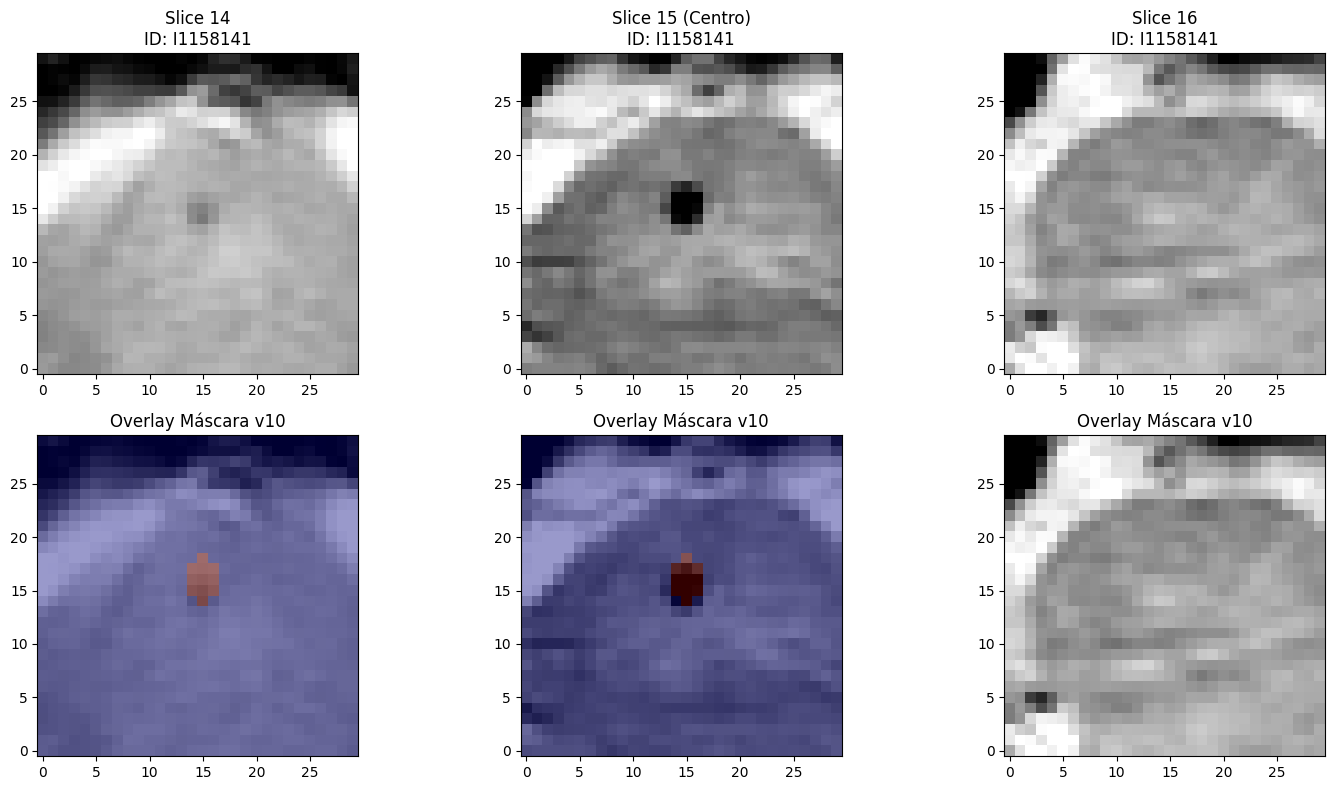

[5] ID: I776226 - Radios calculados con v10.


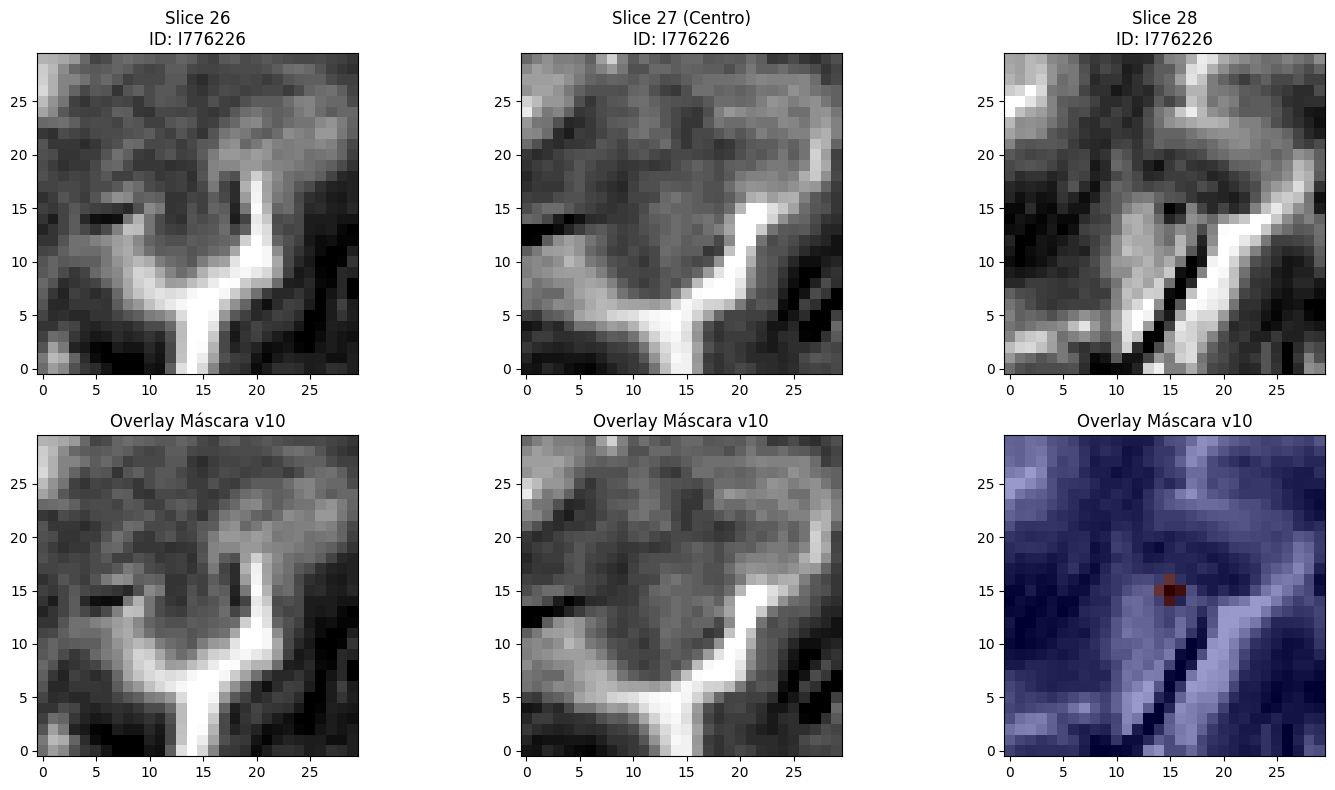

[6] ID: I776226 - Radios calculados con v10.


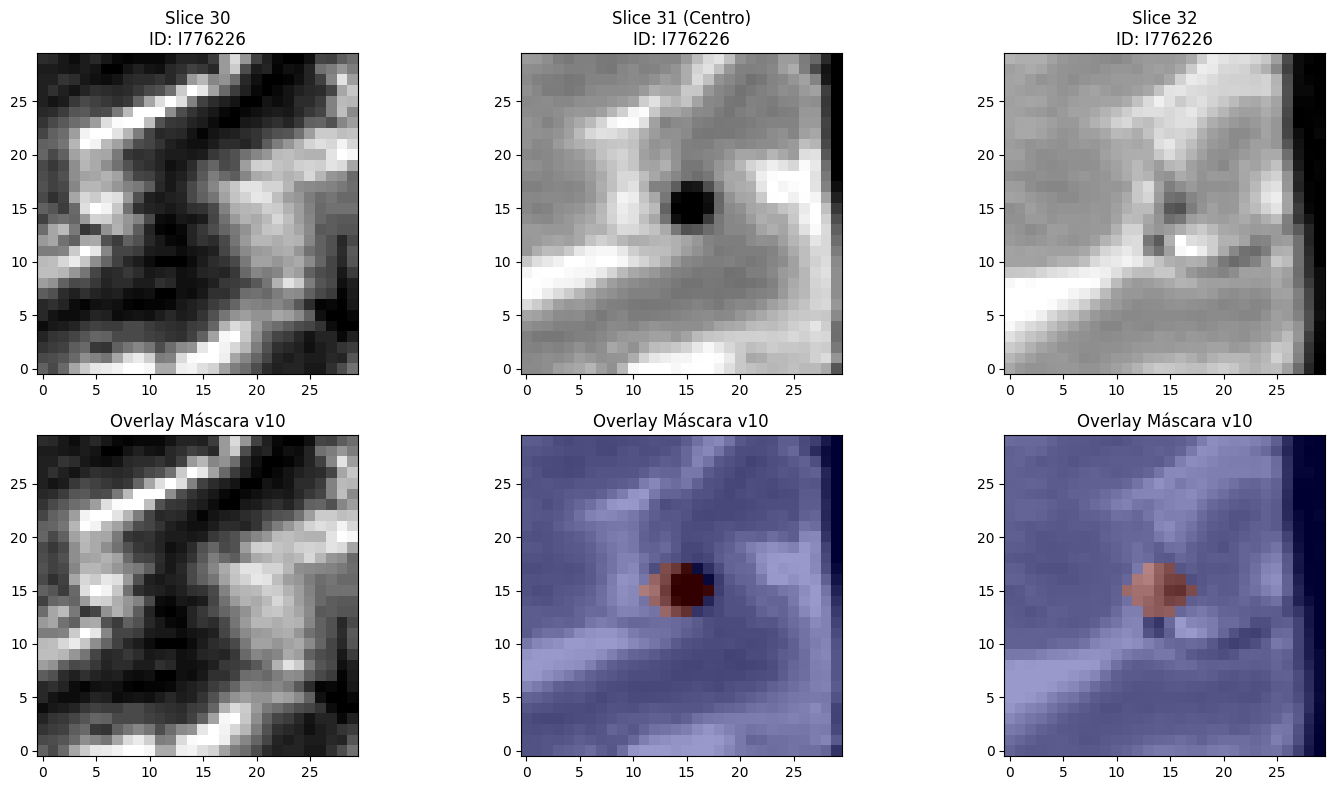

[7] ID: I956600 - Radios calculados con v10.


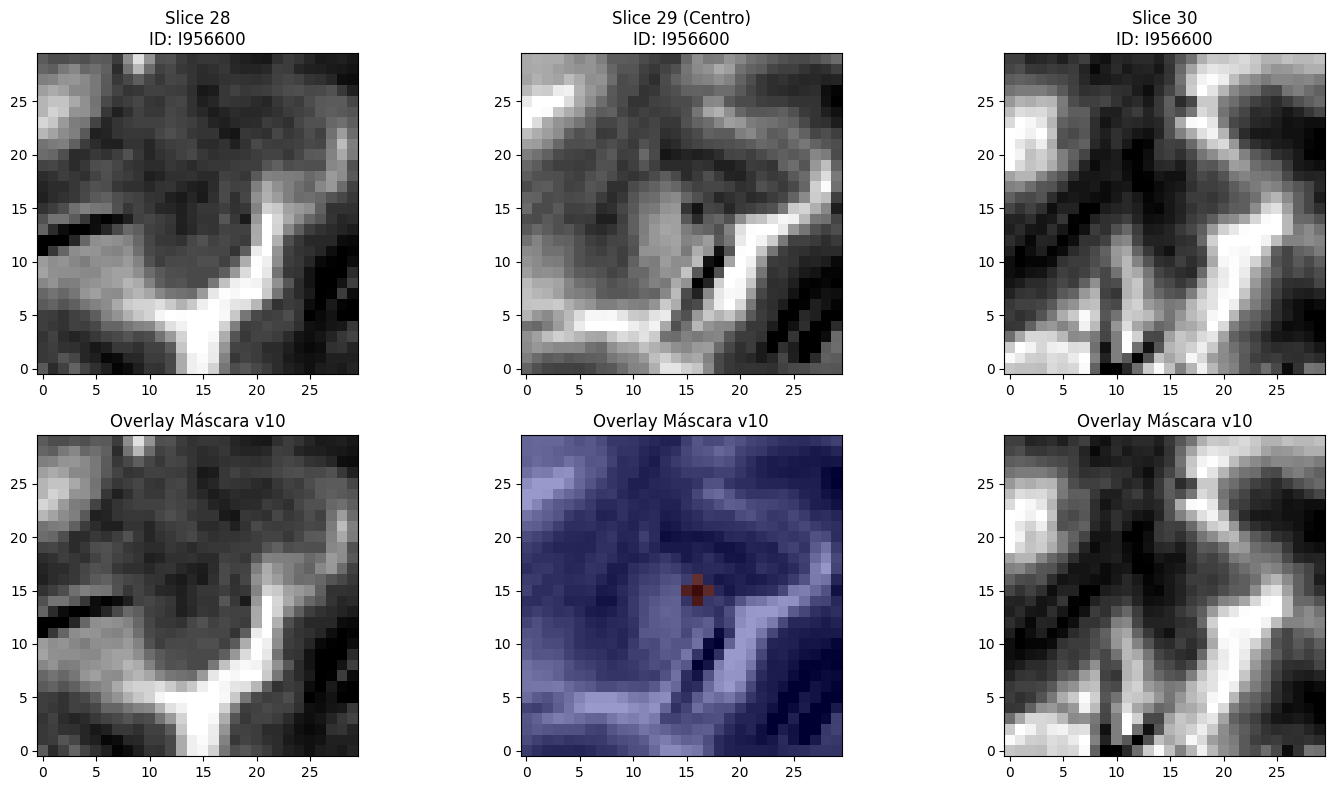

[8] ID: I956600 - Radios calculados con v10.


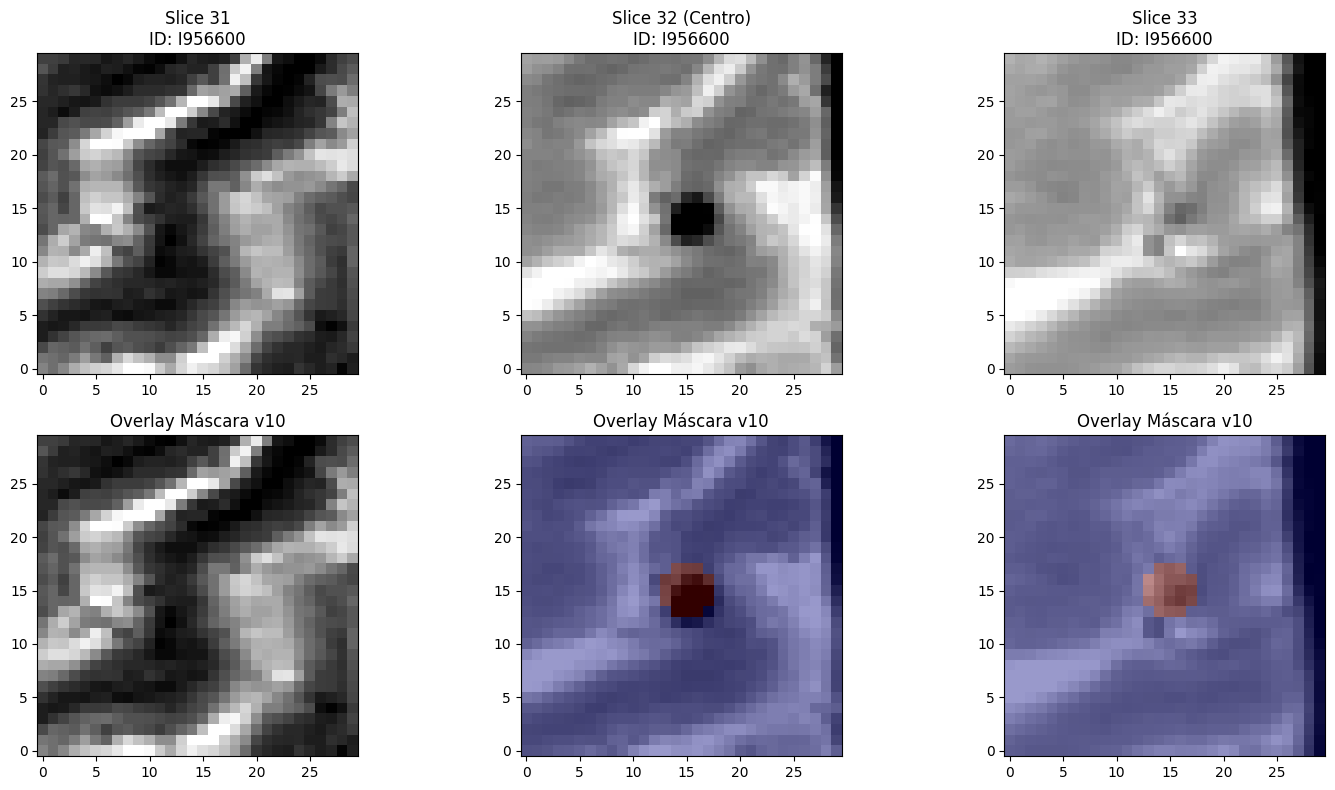

[9] ID: I1119607 - Radios calculados con v10.


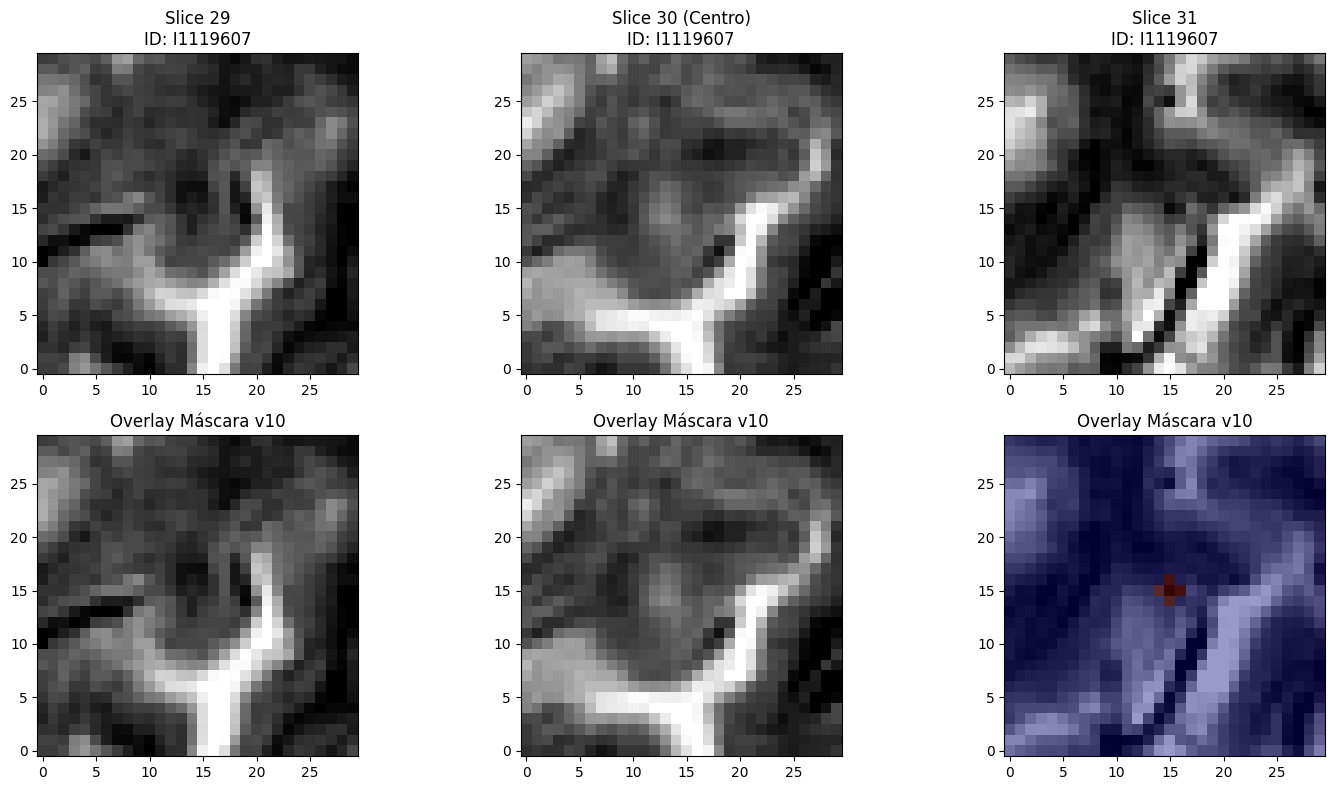

[10] ID: I1119607 - Radios calculados con v10.


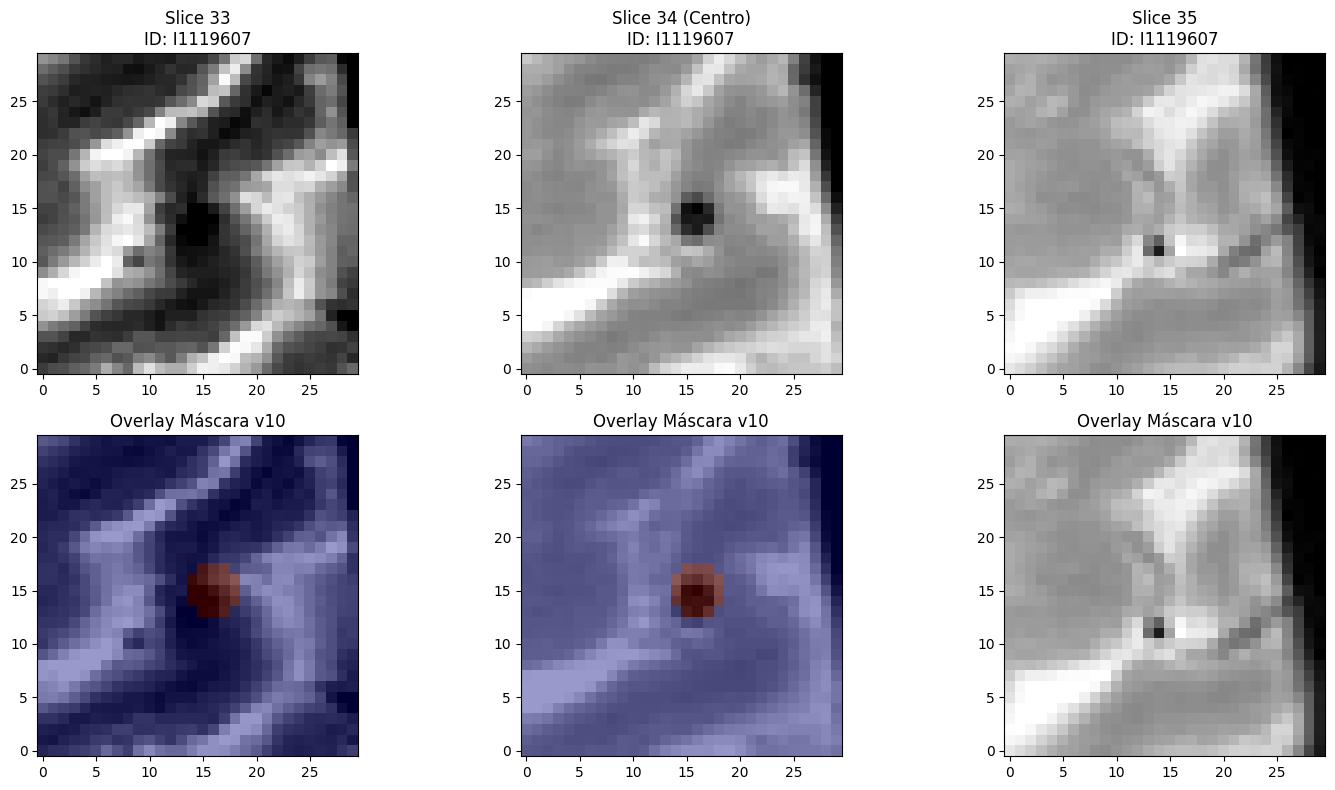

[11] ID: I1278853 - Radios calculados con v10.


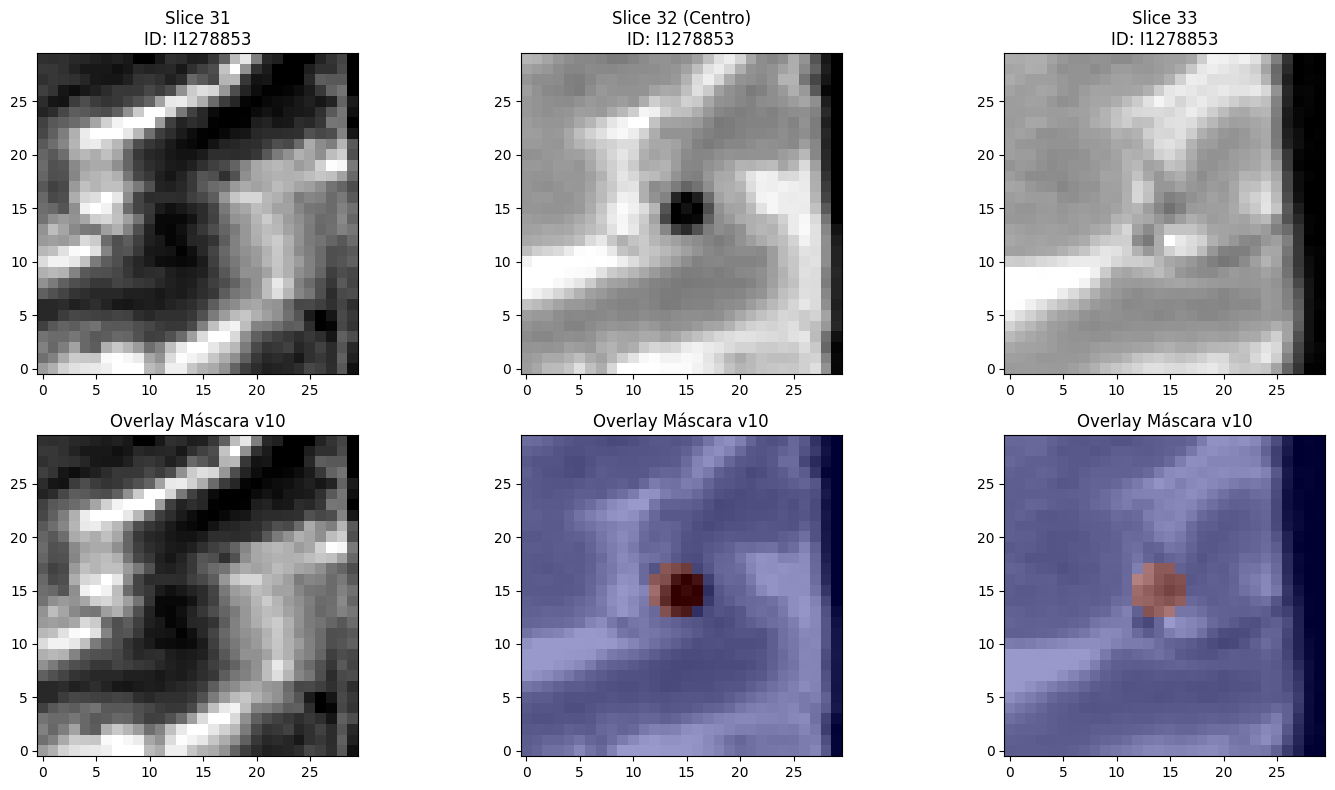

[12] ID: I1278853 - Radios calculados con v10.


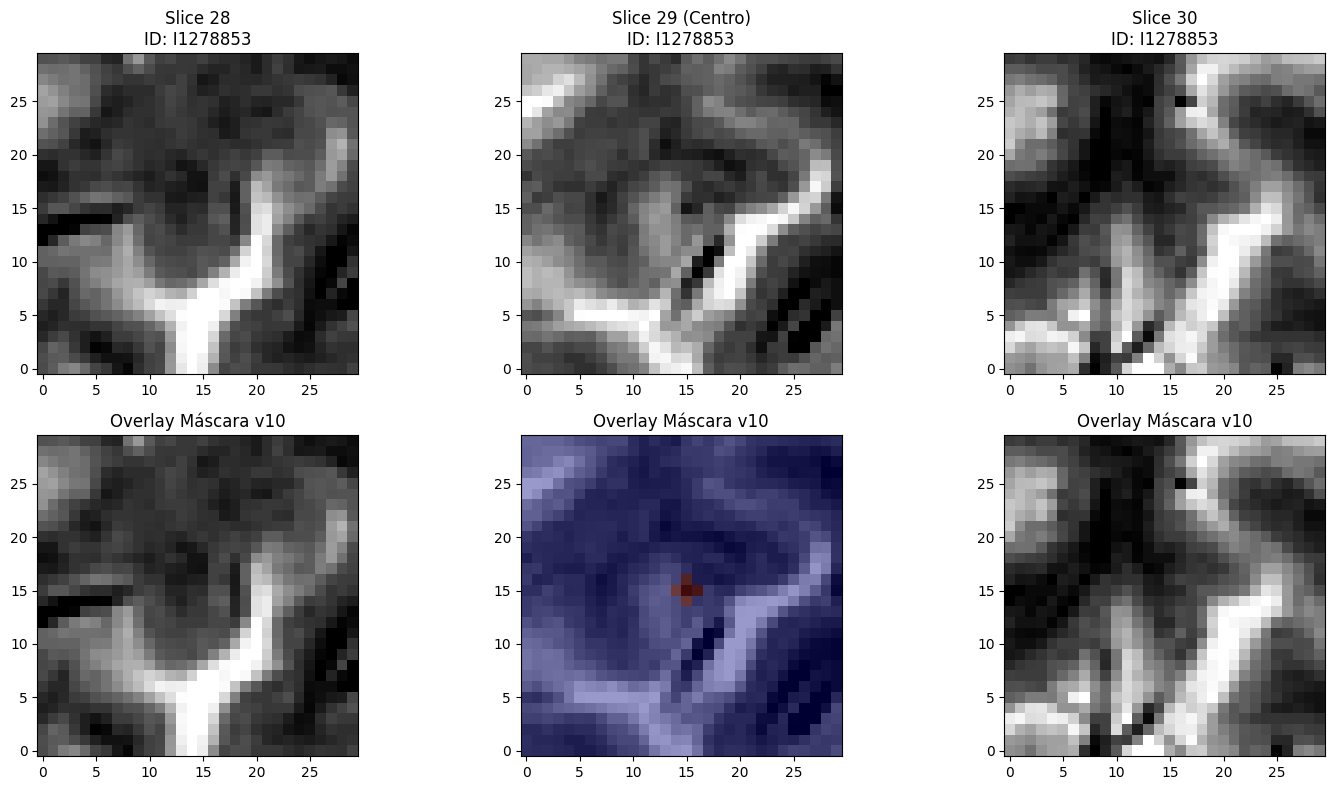

[13] ID: I411279 - Radios calculados con v10.


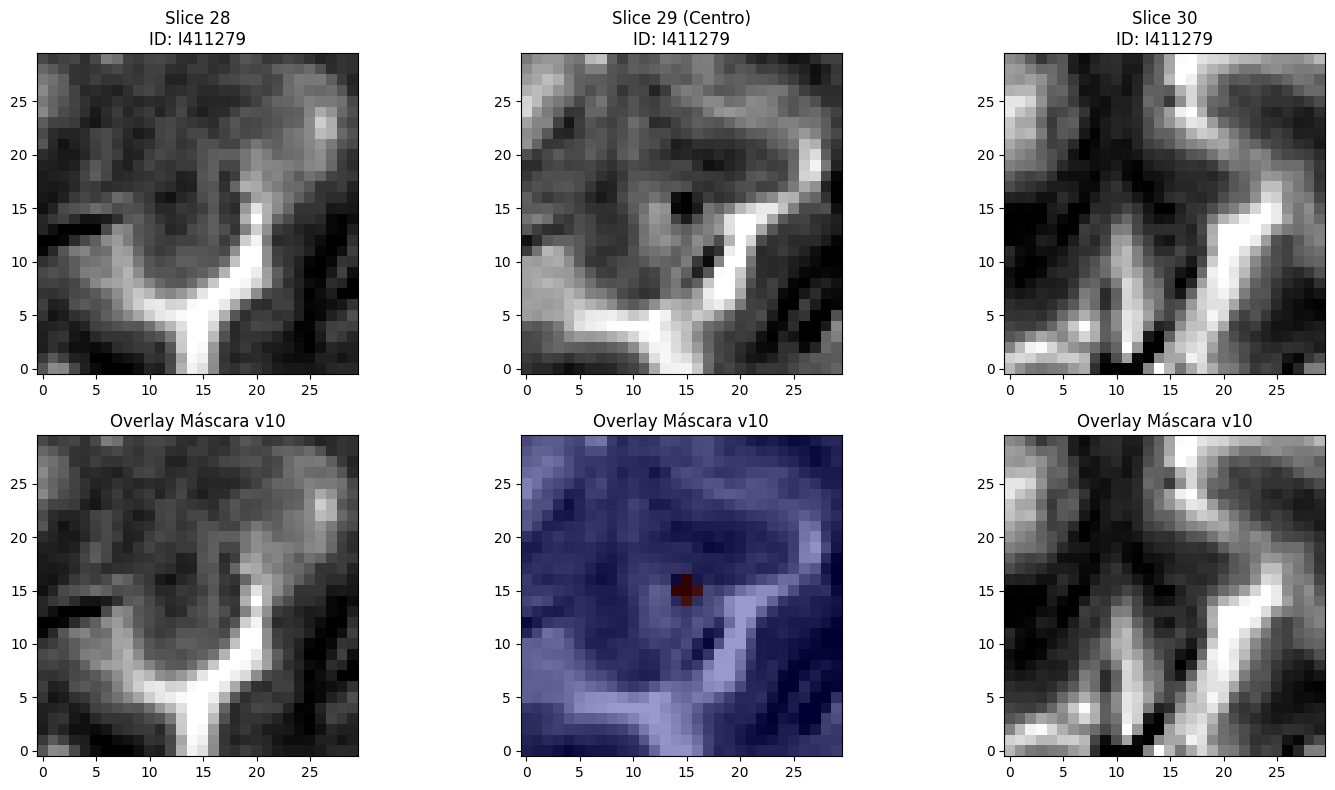

[14] ID: I411279 - Radios calculados con v10.


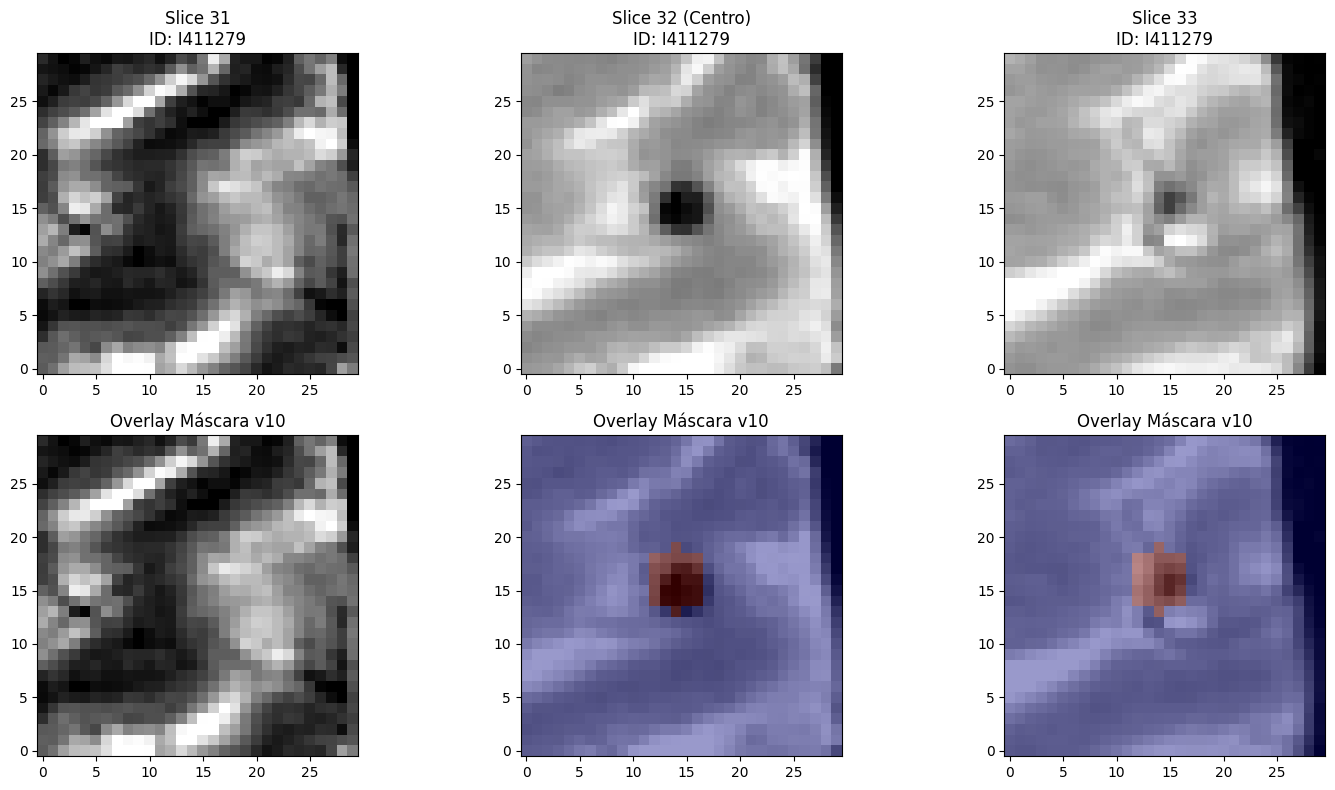

[15] ID: I865962 - Radios calculados con v10.


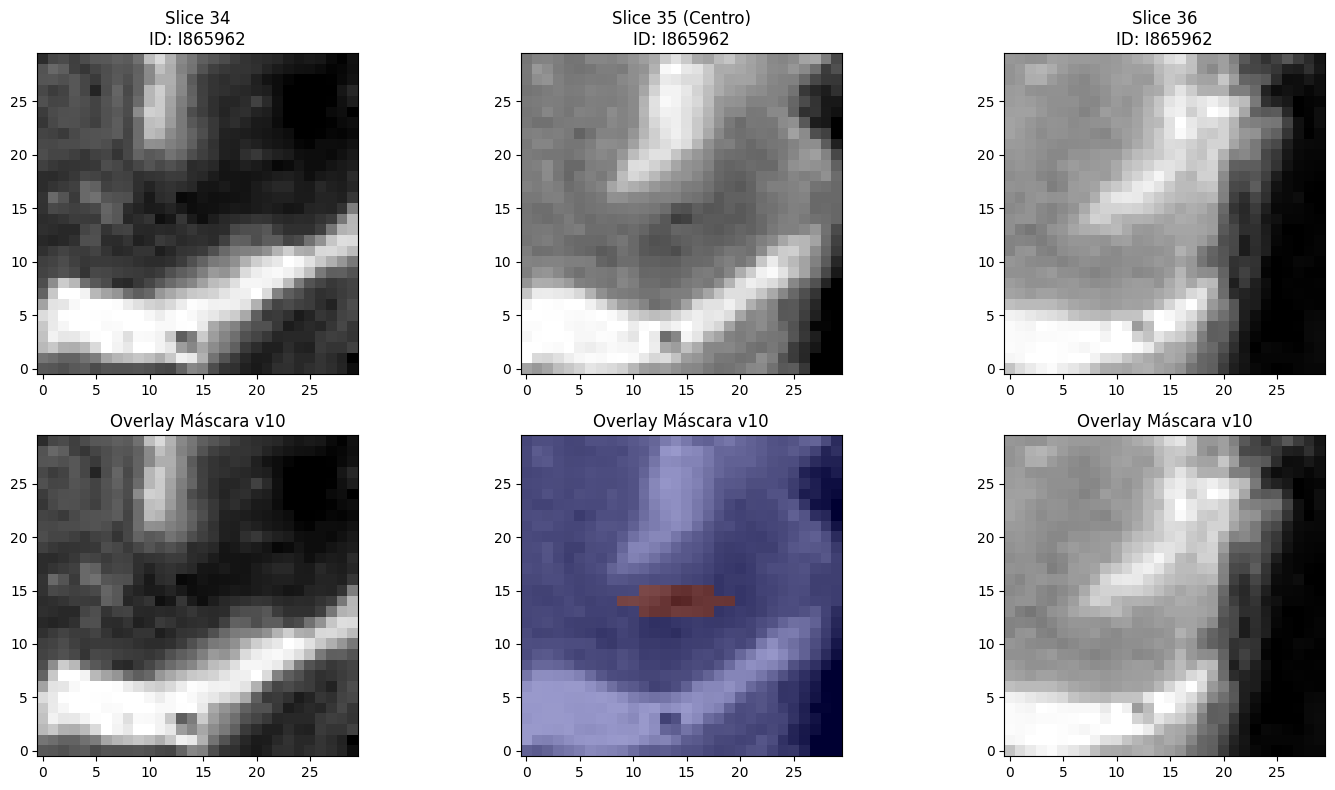

[16] ID: I865962 - Radios calculados con v10.


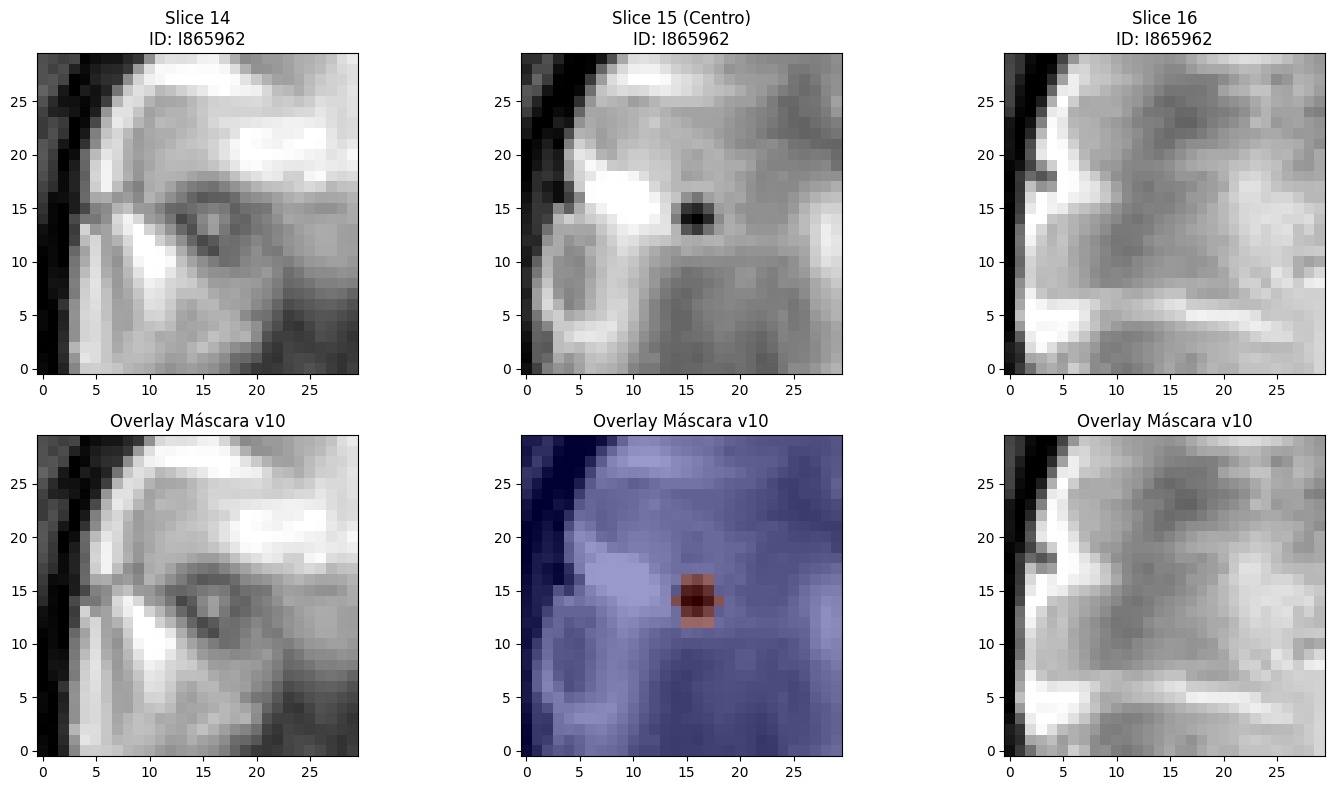

[17] ID: I1058748 - Radios calculados con v10.


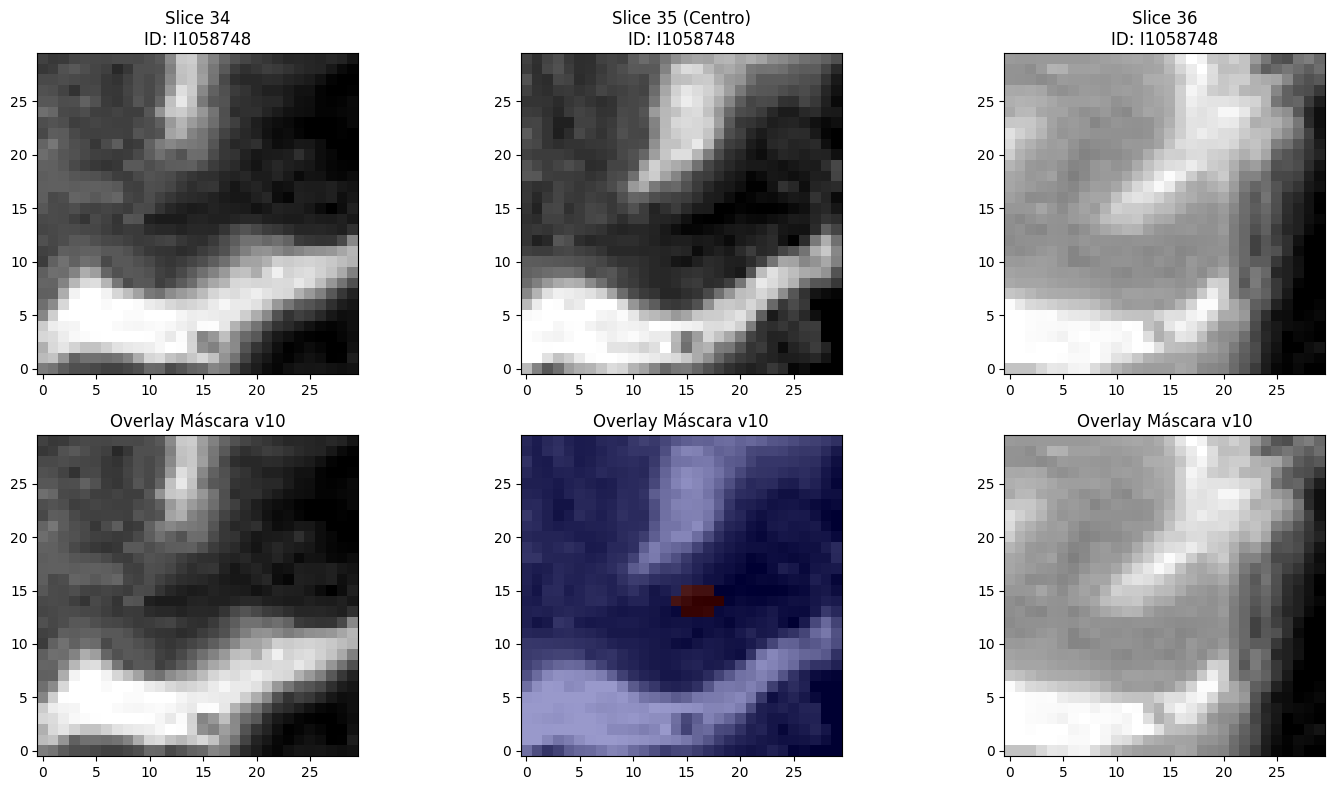

[18] ID: I1058748 - Radios calculados con v10.


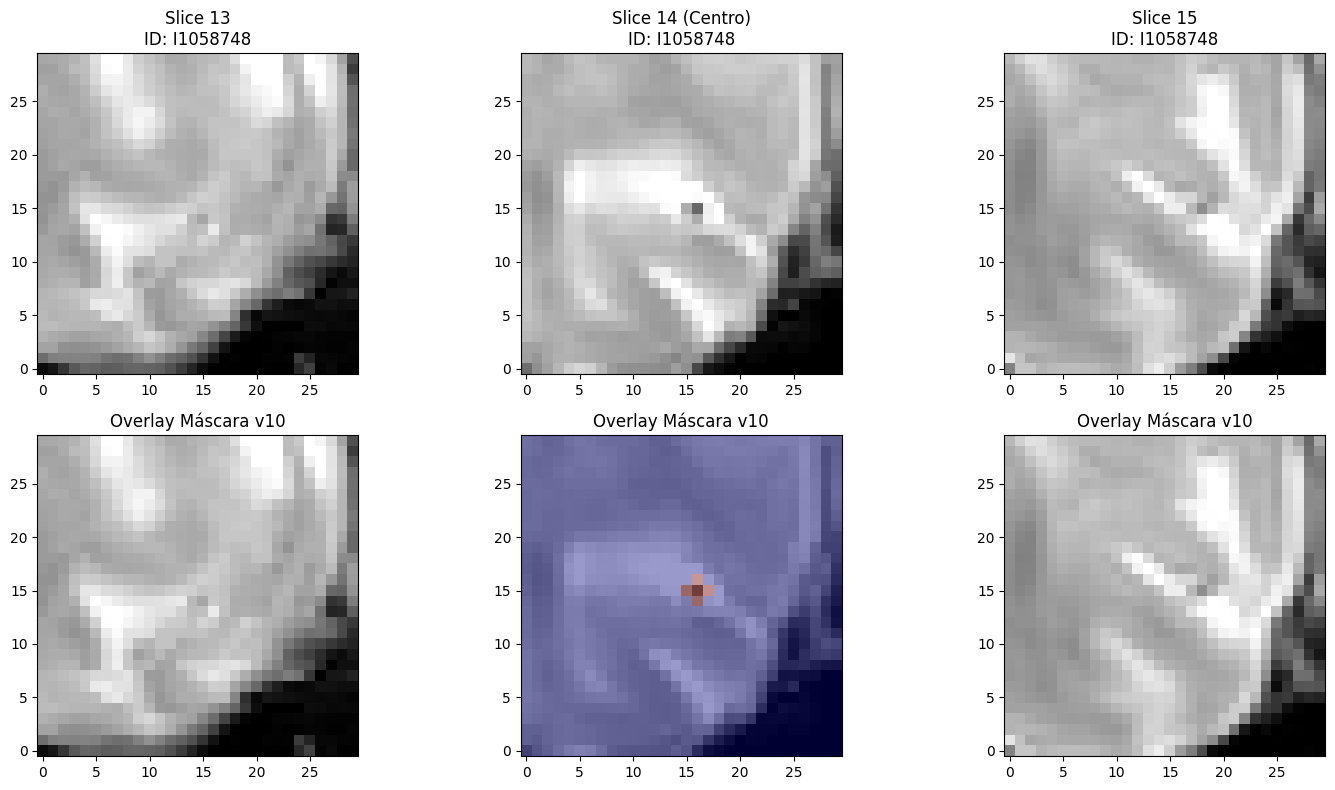

[19] ID: I1058748 - Radios calculados con v10.


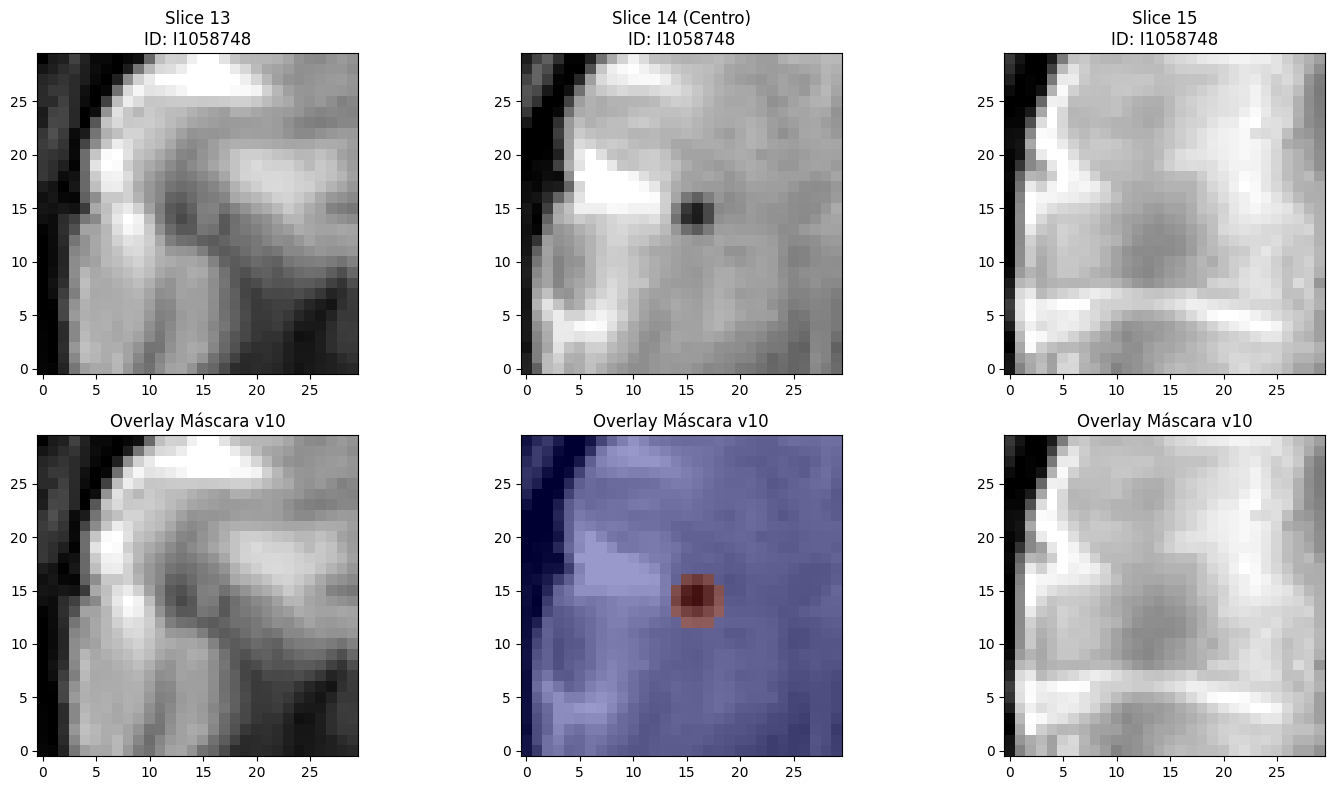

[20] ID: I413870 - Radios calculados con v10.


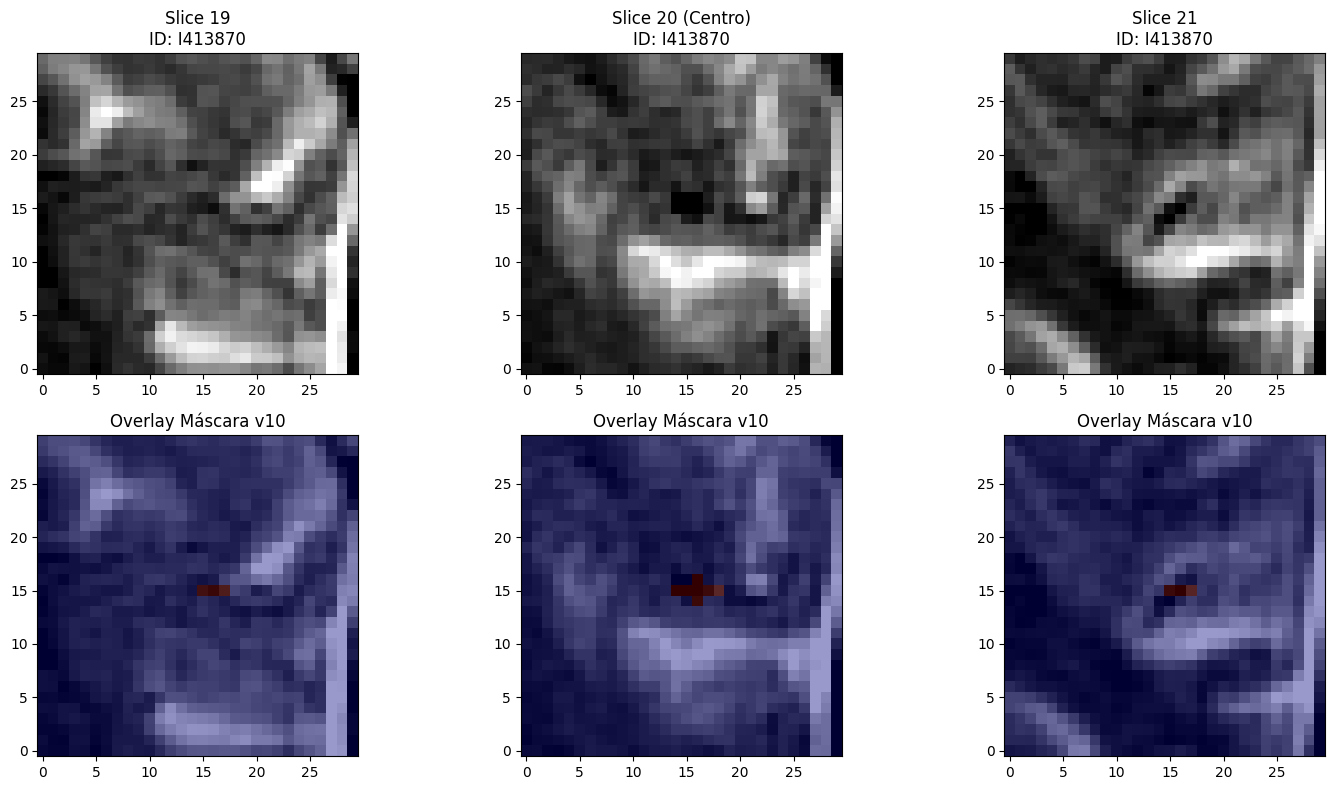

[21] ID: I413870 - Radios calculados con v10.


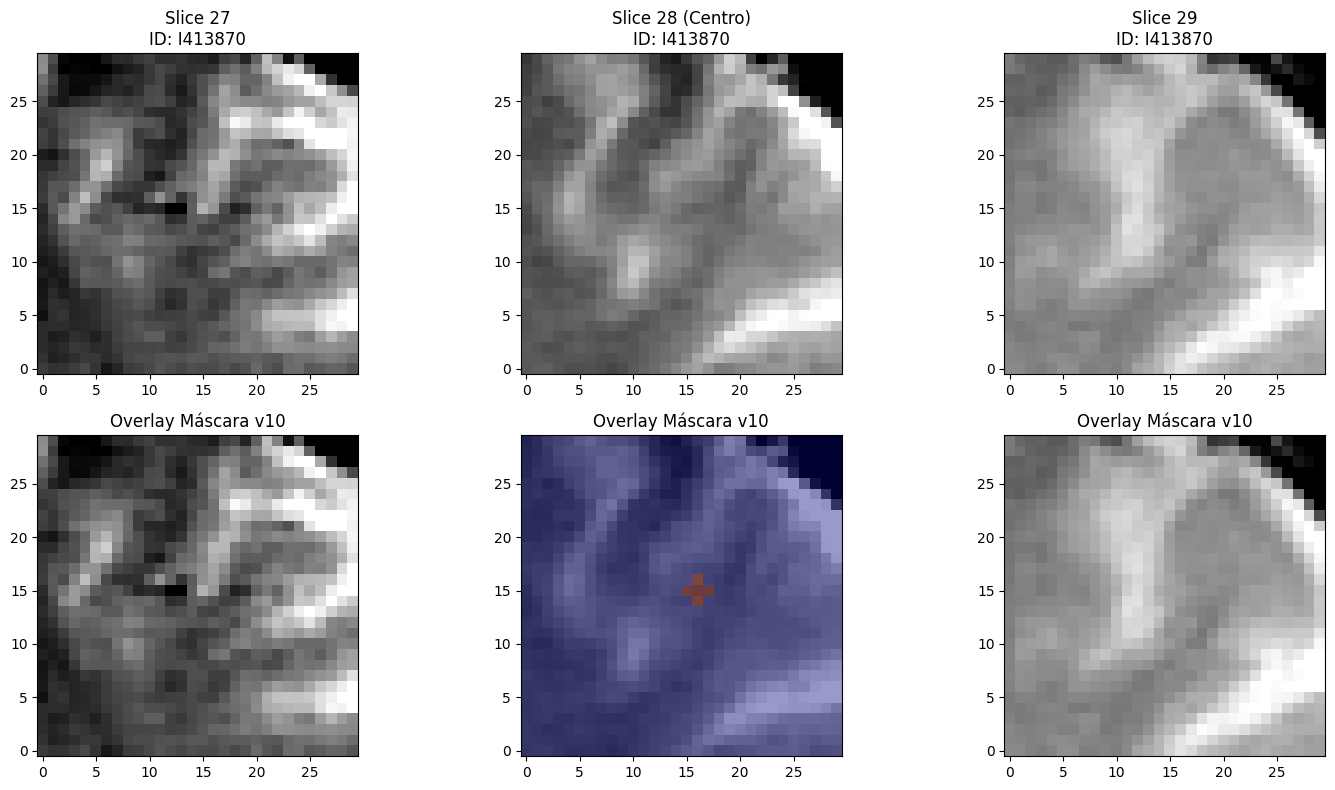

[22] ID: I413870 - Radios calculados con v10.


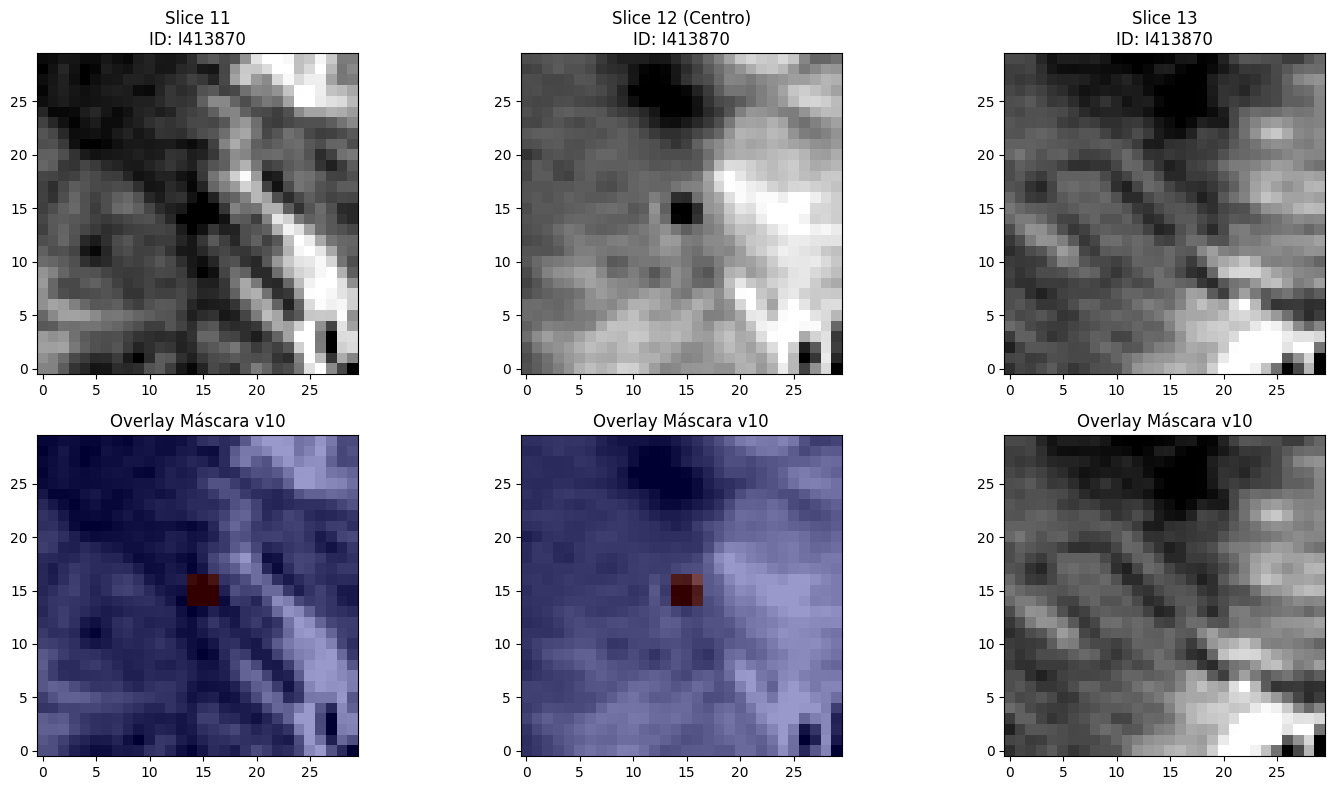

[23] ID: I475761 - Radios calculados con v10.


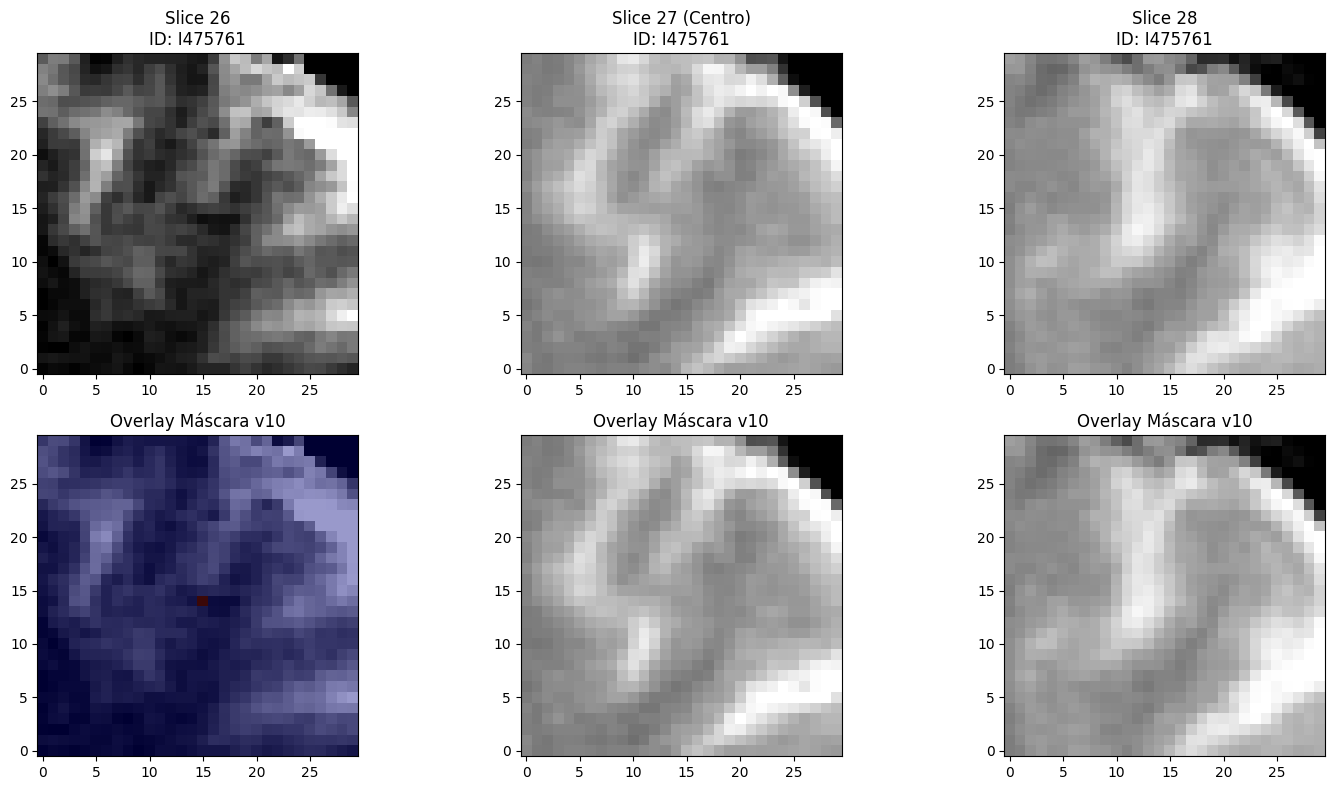

[24] ID: I475761 - Radios calculados con v10.


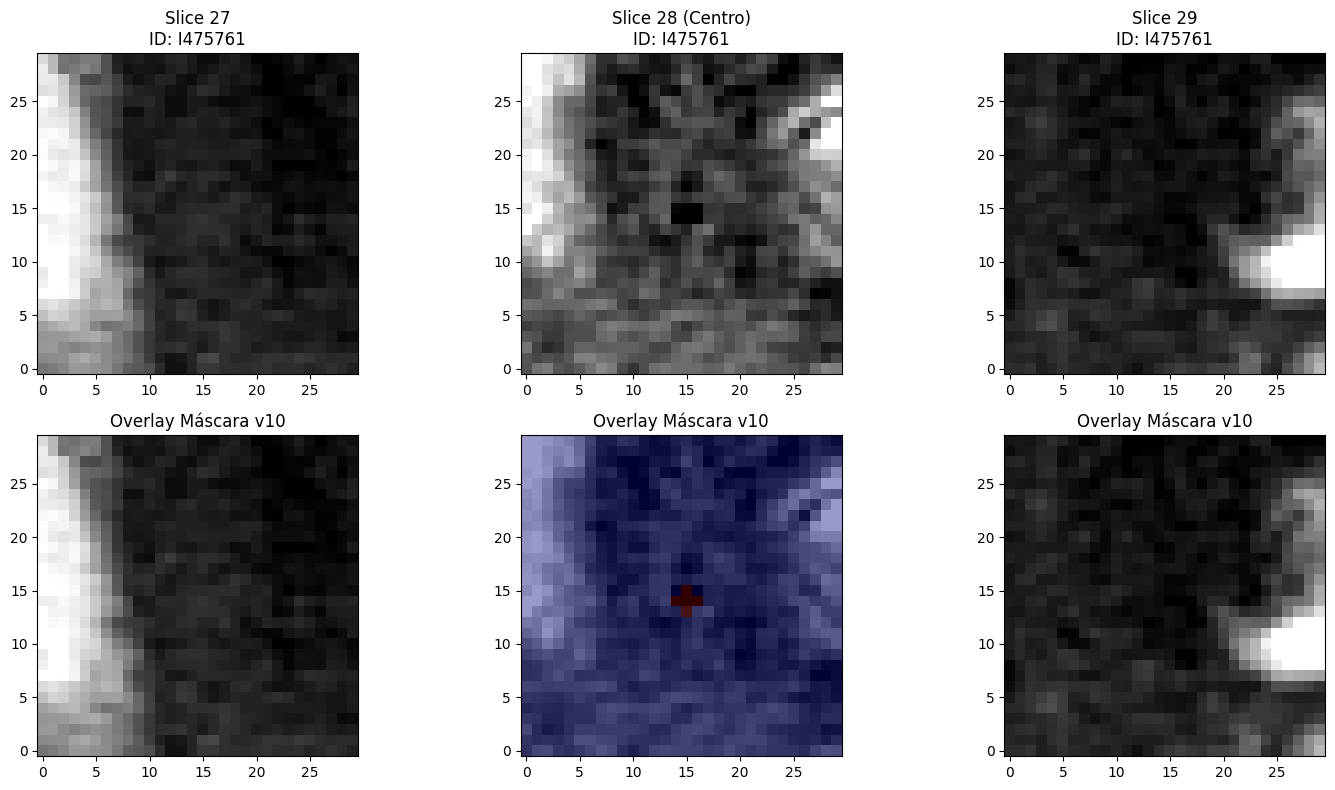

[25] ID: I475761 - Radios calculados con v10.


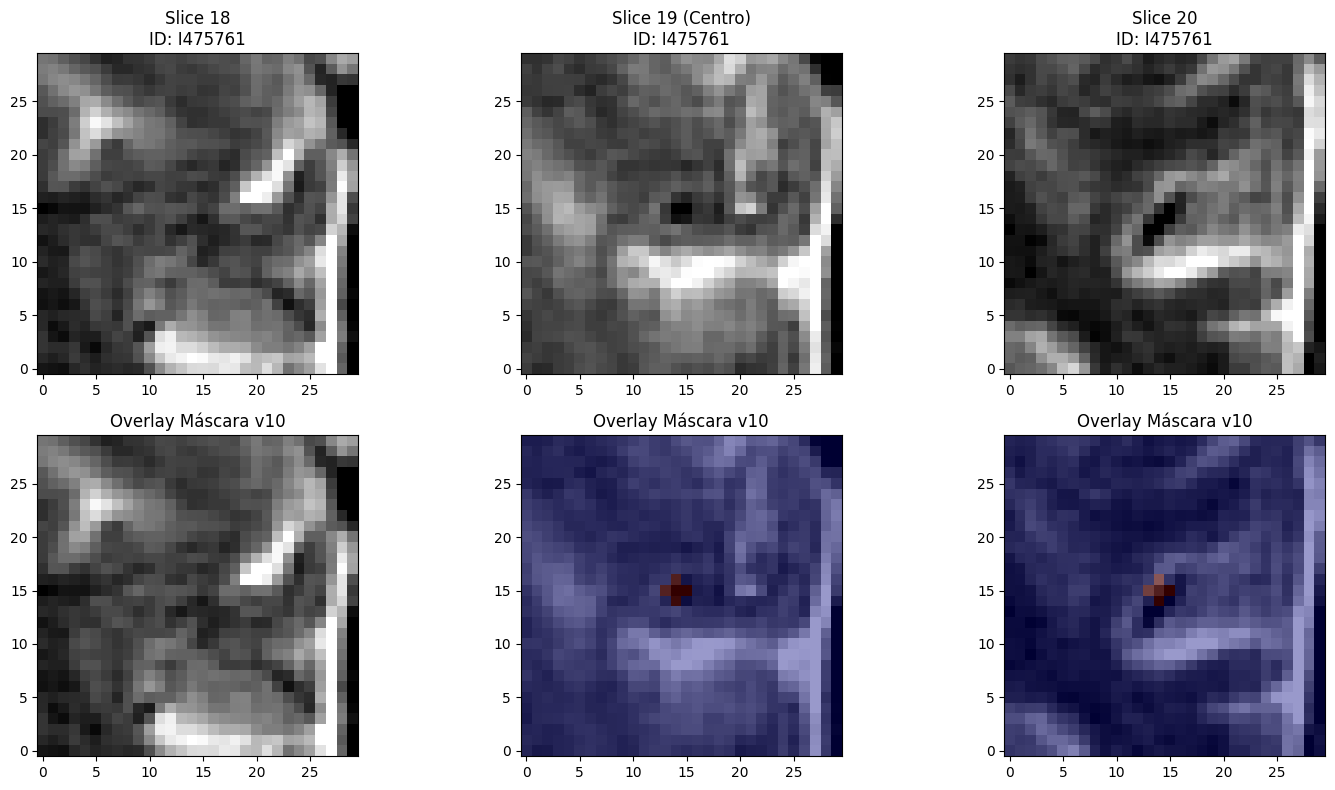

Iniciando procesamiento de 1807 archivos...


Generando Pseudomáscaras:  19%|█▉        | 342/1807 [00:31<04:07,  5.92it/s]

Error de formato en ID I1471143.nii.gz: -40.1241136176373 -58.8555828880366 51.8649601888334 1


Generando Pseudomáscaras:  21%|██        | 372/1807 [00:35<02:00, 11.87it/s]

Error de formato en ID I1509960.nii.gz: 38.2757951617241 -21.3102388679981 -45.8116607666016 1
Error de formato en ID I1509960.nii.gz: 38.809649348259 -26.114926546812 -45.8116607666016 1


Generando Pseudomáscaras:  36%|███▋      | 657/1807 [01:01<01:25, 13.42it/s]


Error procesando I272052.nii.gz: Compressed file ended before the end-of-stream marker was reached


Generando Pseudomáscaras: 100%|██████████| 1807/1807 [02:54<00:00, 10.35it/s]


Procesamiento finalizado. Las máscaras se han guardado en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset/pseudo_labels/positives


In [13]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# CONFIGURACIÓN DE RUTAS
# ==========================================
BASE_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset"
IMAGE_DIR = os.path.join(BASE_PATH, "raw/positives")
MASK_OUT_DIR = os.path.join(BASE_PATH, "pseudo_labels/positives")
CSV_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/ADNI_original_dataset_downloaded/MAYOADIRL_MRI_MCH_12Feb2026.csv"
os.makedirs(MASK_OUT_DIR, exist_ok=True)

# ==========================================
# CONFIGURACIÓN DE PARÁMETROS (Versión 11)
# ==========================================
UMBRAL_AXIAL = 0.70      # % del fondo local para radios X, Y
UMBRAL_Z = 0.72          # % del fondo local para conectividad Z
DIST_RADIAL_Z = 1.8      # mm de tolerancia de desplazamiento en Z
FACTOR_Z = 1.2           # Multiplicador de compensación para espesor de corte
MAX_RADIO_MM = 8.0       # Límite físico de la rCMB
# ==========================================

def generate_mask_v11(img_obj, ras_coords):
    img_data = img_obj.get_fdata()
    pixdim = img_obj.header.get_zooms()[:3]
    affine = img_obj.affine
    
    # 1. Mapeo Afín (RAS a Voxel)
    vox_f = (np.linalg.inv(affine) @ np.append(ras_coords, 1))[:3]
    c_base = np.round(vox_f).astype(int)
    
    # --- RECENTRADO 3D (Actualizado para V11) ---
    # Buscamos el punto más oscuro en un entorno 3D (X, Y, Z)
    z_low = max(0, c_base[2]-1)
    z_high = min(img_data.shape[2], c_base[2]+2)
    
    # ROI de 3x3x3 (o 3x3x2 si está en los extremos)
    roi_seed = img_data[c_base[0]-1:c_base[0]+2, 
                        c_base[1]-1:c_base[1]+2, 
                        z_low:z_high]
    
    min_off = np.unravel_index(np.argmin(roi_seed), roi_seed.shape)
    # Definimos el nuevo centro entero (c_int) basado en el mínimo absoluto detectado
    c_int = [c_base[0]-1+min_off[0], 
             c_base[1]-1+min_off[1], 
             z_low+min_off[2]]

    # 2. Caracterización del Fondo Local (Basado en el nuevo centro)
    bg_roi = img_data[max(0,c_int[0]-10):min(img_data.shape[0],c_int[0]+11), 
                      max(0,c_int[1]-10):min(img_data.shape[1],c_int[1]+11), c_int[2]]
    bg_val = np.percentile(bg_roi, 75)
    
    # 3. Radios Axiales (X, Y)
    radii_mm = []
    for axis in [0, 1]:
        lengths = []
        for direction in [1, -1]:
            d = 1
            while d * pixdim[axis] < MAX_RADIO_MM:
                coord = list(c_int); coord[axis] += d * direction
                if not (0 <= coord[axis] < img_data.shape[axis]): break
                if img_data[tuple(coord)] >= bg_val * UMBRAL_AXIAL: break
                d += 1
            lengths.append(d * pixdim[axis])
        radii_mm.append(np.mean(lengths))
    
    # 4. Conectividad Z (Multi-corte)
    z_slices = [c_int[2]]
    for z_dir in [1, -1]:
        nz = c_int[2] + z_dir
        if 0 <= nz < img_data.shape[2]:
            search_r = int(3.5 / pixdim[0]) 
            roi_z = img_data[c_int[0]-search_r:c_int[0]+search_r+1, 
                             c_int[1]-search_r:c_int[1]+search_r+1, nz]
            
            min_val_z = np.min(roi_z)
            min_loc_z = np.unravel_index(np.argmin(roi_z), roi_z.shape)
            
            dist_rad = np.sqrt(((min_loc_z[0]-search_r)*pixdim[0])**2 + 
                               ((min_loc_z[1]-search_r)*pixdim[1])**2)
            
            if dist_rad < DIST_RADIAL_Z and min_val_z < bg_val * UMBRAL_Z:
                z_slices.append(nz)
    
    z_min, z_max = min(z_slices), max(z_slices)
    z_center_f = (z_min + z_max) / 2.0
    r_z_mm = ((z_max - z_min) * pixdim[2] + pixdim[2] * FACTOR_Z) / 2.0
    
    # 5. Modelado del Elipsoide
    r_mm = [radii_mm[0], radii_mm[1], r_z_mm]
    c_final = [float(c_int[0]), float(c_int[1]), z_center_f]
    
    final_mask = np.zeros(img_data.shape, dtype=np.uint8)
    margin = [int(r/p) + 2 for r, p in zip(r_mm, pixdim)]
    
    X, Y, Z = np.ogrid[max(0,int(c_final[0]-margin[0])):min(img_data.shape[0],int(c_final[0]+margin[0])),
                       max(0,int(c_final[1]-margin[1])):min(img_data.shape[1],int(c_final[1]+margin[1])),
                       max(0,int(c_final[2]-margin[2])):min(img_data.shape[2],int(c_final[2]+margin[2]))]
    
    dist_sq = ((X - c_final[0]) * pixdim[0] / r_mm[0])**2 + \
              ((Y - c_final[1]) * pixdim[1] / r_mm[1])**2 + \
              ((Z - c_final[2]) * pixdim[2] / r_mm[2])**2
              
    # Se corrige a 1.0 para seguir la definición matemática estricta del elipsoide
    final_mask[X, Y, Z] = (dist_sq <= 1.0) 
    
    return final_mask


def show_multislice_comparison(img_obj, mask_data, ras_coords, tipo_label, title=""):
    """
    Mantiene estrictamente tu formato pero corrige la obtención de voxels 
    desde coordenadas RAS para evitar el error de 'no ver nada'.
    """
    # 1. Convertir RAS a Voxel en el espacio de la imagen original
    affine_img = img_obj.affine
    inv_affine_img = np.linalg.inv(affine_img)
    vox_coords = (inv_affine_img @ np.append(ras_coords, 1))[:3]
    
    # Coordenadas enteras para indexar el array
    x, y, z = np.round(vox_coords).astype(int)
    img_data = img_obj.get_fdata()

    # --- TU FORMATO DE VISUALIZACIÓN ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Definir el parche (zoom)
    x_min, x_max = max(0, x-15), min(img_data.shape[0], x+15)
    y_min, y_max = max(0, y-15), min(img_data.shape[1], y+15)
    
    # Slices en el eje Z de la imagen original
    slices = [z-1, z, z+1]
    titles = [f"Slice {z}", f"Slice {z+1} (Centro)", f"Slice {z+2}"]

    for i, s in enumerate(slices):
        if 0 <= s < img_data.shape[2]:
            img_patch = img_data[x_min:x_max, y_min:y_max, s]
            mask_patch = mask_data[x_min:x_max, y_min:y_max, s]
            
            # Fila 0: SWI/T2* original
            # Usamos vmin/vmax basados en el percentil del parche para que 'se vea algo' 
            # incluso si hay mucha diferencia de intensidad
            axes[0, i].imshow(img_patch.T, cmap='gray', origin='lower', 
                              vmin=np.percentile(img_patch, 2), vmax=np.percentile(img_patch, 98))
            axes[0, i].set_title(f"{titles[i]}\n{title}")
            
            # Fila 1: Overlay
            axes[1, i].imshow(img_patch.T, cmap='gray', origin='lower',
                              vmin=np.percentile(img_patch, 2), vmax=np.percentile(img_patch, 98))
            # Solo dibujamos la máscara si tiene algún voxel positivo
            if np.any(mask_patch):
                axes[1, i].imshow(mask_patch.T, cmap='jet', alpha=0.4, origin='lower')
            axes[1, i].set_title(f"Overlay Máscara {tipo_label}")
        else:
            axes[0, i].text(0.5, 0.5, 'Slice fuera de rango', ha='center')
            axes[1, i].text(0.5, 0.5, 'Slice fuera de rango', ha='center')
    
    plt.tight_layout()
    plt.show()

# --- INTEGRACIÓN CON LA PRUEBA DE LOS 10 PRIMEROS ---
def probar_visualizacion_corregida():
    df = pd.read_csv(CSV_PATH)
    exitos = 0
    for _, row in df.iterrows():
        if exitos >= 25: break
        
        id_num = str(row['LONI_IMG_ID']).split('.')[0].strip()
        if not id_num.startswith('I'): id_num = f"I{id_num}"
        
        img_path = os.path.join(IMG_DIR, f"{id_num}.nii.gz")
        if os.path.exists(img_path):
            img_obj = nib.load(img_path)
            ras = np.array([float(x) for x in str(row['RASLOCATIONS']).split()[:3]])
            
            # Generar máscara (usando la función optimizada anterior)
            mask = generate_mask_v11(img_obj, ras)
            
            print(f"[{exitos+1}] ID: {id_num} - Radios calculados con v10.")

            # Llamar a tu función visual con los datos corregidos
            show_multislice_comparison(img_obj, mask, ras, tipo_label="v10", title=f"ID: {id_num}")
            exitos += 1

probar_visualizacion_corregida()

# Generamos pseudomáscaras
# --- PREPARACIÓN DE DATOS ---
df = pd.read_csv(CSV_PATH)

# Normalización de IDs en el CSV (Quitamos 'I', quitamos decimales y espacios)
df['ID_MATCH'] = df['LONI_IMG_ID'].astype(str).str.replace('I', '').str.split('.').str[0].str.strip()

# Listado de archivos físicos en la carpeta
all_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".nii.gz")]

print(f"Iniciando procesamiento de {len(all_files)} archivos...")

# --- BUCLE DE PROCESAMIENTO MASIVO ---
for filename in tqdm(all_files, desc="Generando Pseudomáscaras"):
    # Limpiamos el nombre del archivo para buscarlo en el CSV
    img_id_clean = filename.replace("I", "").replace(".nii.gz", "").strip()
    
    # Filtramos todas las filas que correspondan a este scan (pueden ser varias lesiones)
    rows = df[df['ID_MATCH'] == img_id_clean]
    
    if rows.empty:
        continue
    
    try:
        # Cargamos el objeto NIfTI una sola vez por scan
        img_obj = nib.load(os.path.join(IMAGE_DIR, filename))
        
        # Creamos una máscara maestra vacía (del mismo tamaño que la imagen)
        # Usamos uint8 para ahorrar espacio
        master_mask = np.zeros(img_obj.shape, dtype=np.uint8)
        
        # Iteramos por cada lesión reportada para este ID
        for _, row in rows.iterrows():
            if pd.isna(row['RASLOCATIONS']):
                continue
            
            raw_val = str(row['RASLOCATIONS'])

            ## AÑADIMOS LIMPIEZA DE DATOS PARA EVITAR LOS VALUE ERRORS
            # 1. Limpieza agresiva: quitamos comillas simples, dobles y espacios en los extremos
            clean_val = raw_val.replace("'", "").replace('"', "").strip()
    
            if not clean_val or clean_val.lower() == "nan":
                continue
                
            try:
                # 2. Dividimos por espacios y tomamos solo los 3 primeros (X, Y, Z)
                parts = clean_val.split()
                if len(parts) < 3:
                    continue
                    
                # Convertimos a float cada parte
                ras = np.array([float(parts[0]), float(parts[1]), float(parts[2])])
                
                # 3. Proceder con la generación de máscara
                mask_ind = generate_mask_v11(img_obj, ras)
                # ... resto del código ...
                
            except ValueError as e:
                print(f"Error de formato en ID {filename}: {clean_val}")
                continue

            # Generamos la máscara individual con tu función v11
            mask_ind = generate_mask_v11(img_obj, ras)
            
            # Combinamos con la máscara maestra usando el máximo (para no solapar)
            master_mask = np.maximum(master_mask, mask_ind)
            
        # Una vez procesadas todas las lesiones del scan, guardamos el archivo único
        new_img = nib.Nifti1Image(master_mask, img_obj.affine, img_obj.header)
        nib.save(new_img, os.path.join(MASK_OUT_DIR, filename))
        
    except Exception as e:
        print(f"\nError procesando {filename}: {e}")
        continue

print(f"\nProcesamiento finalizado. Las máscaras se han guardado en: {MASK_OUT_DIR}")


## Caracterización pseudomáscaras

In [5]:
print(stats_dist)

print(stats_morf)

{'Media_CMBs_por_scan': np.float64(2.679073033707865), 'Desviación_CMBs_por_scan': np.float64(19.564464684807856), 'Total_CMBs_anotadas': 15260}
      Volume_mm3  Elongation  Intensity_Mean  Intensity_Centroid
mean   70.782648    0.338933      426.022400          342.353434
std   156.303589    0.149337      263.014442          243.578672


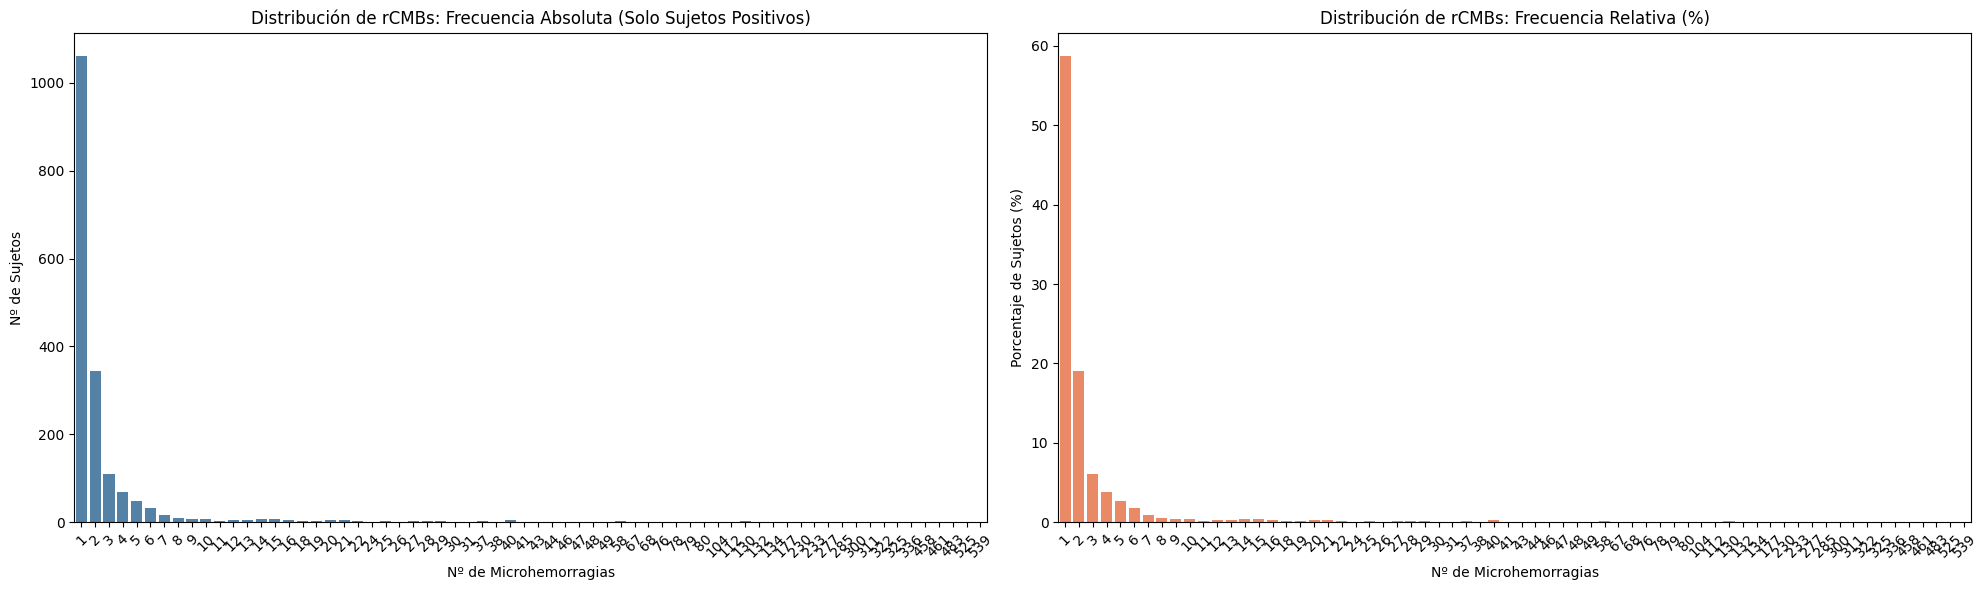

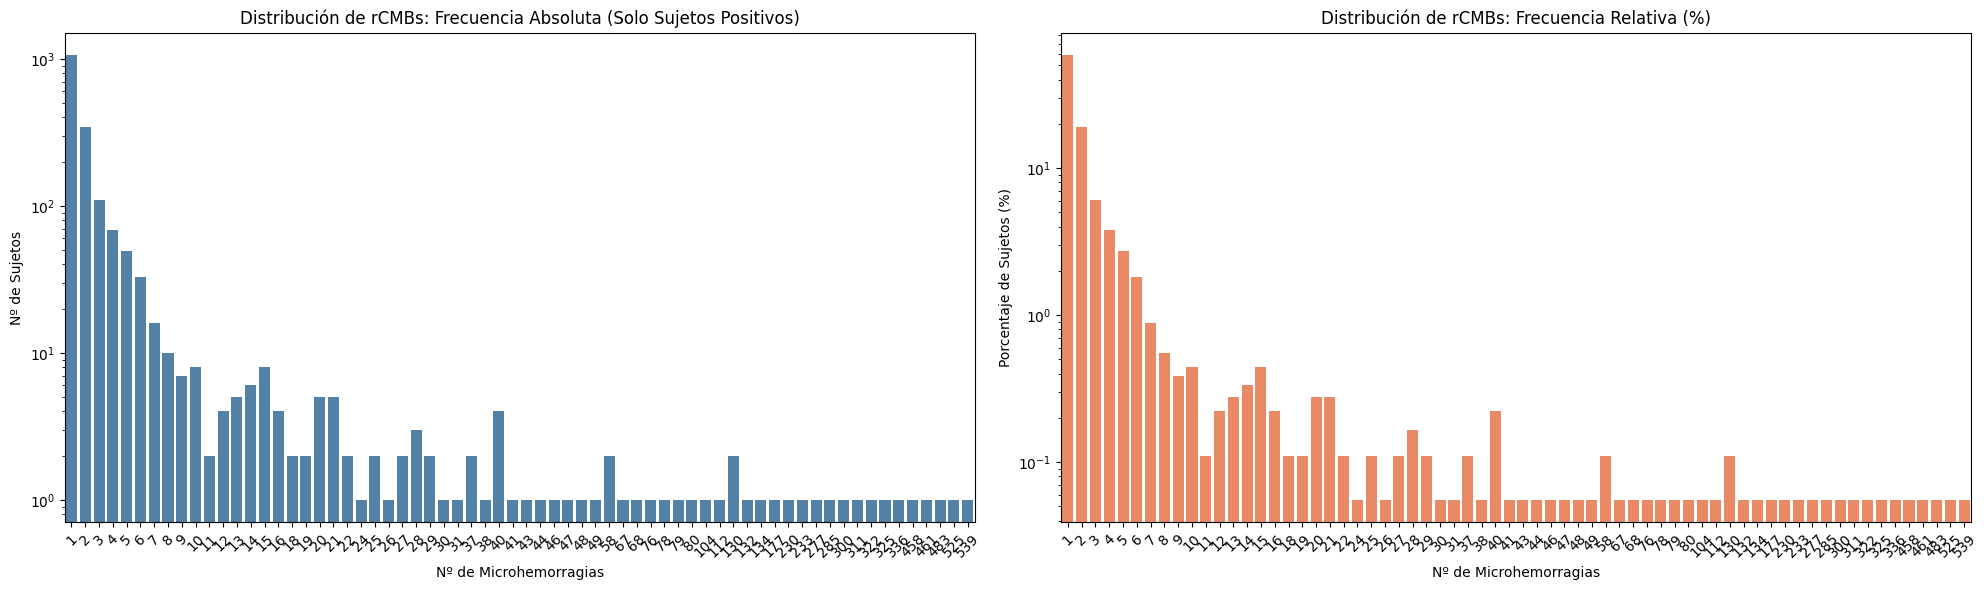

Analizando: 100%|██████████| 1807/1807 [11:15<00:00,  2.67it/s]


       ANÁLISIS EXCLUSIVO: SUJETOS POSITIVOS ADNI

### 1. ESTADÍSTICAS DE CARGA LESIONAL ###
Nº total de scans positivos analizados: 1807
Media de rCMBs por scan (Positivos): 6.29
Desviación típica: 34.47
Rango de lesiones detectado: 1 - 539

### 2. MORFOMETRÍA E INTENSIDAD (Media ± Desviación) ###
                   Resumen (Mean ± STD)
Volume_mm3          110.8796 ± 243.2090
Elongation              0.3379 ± 0.1366
Intensity_Mean      389.3864 ± 238.3161
Intensity_Centroid  312.6626 ± 223.9569

### 3. TOP 10 REGIONES ATLAS ADNI (En población positiva) ###
ATLASREGIONS
SC_front_L     1820
SC_front_R     1543
SC_pariet_L    1394
SC_temp_L      1151
SC_temp_R      1103
SC_pariet_R    1081
SC_occip_L      993
SC_occip_R      784
cerebellum      615
brainstem       112

### 4. TOP 10 ETIQUETAS SYNTHSEG (En centroide de rCMBs) ###
SynthSeg_Label
2.0       943
41.0      816
24.0      536
1028.0    174
1008.0    173
1027.0    172
1011.0    141
2008.0    138
1029.0    135
2028.0    124


In [19]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops
from tqdm import tqdm
from nilearn.image import resample_to_img

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset"
IMAGE_DIR = os.path.join(BASE_PATH, "raw/positives")
MASK_DIR = os.path.join(BASE_PATH, "pseudo_labels/positives")
SEG_DIR = os.path.join(BASE_PATH, "synthseg_segmentations") 
CSV_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/ADNI_Master_Unified_Dataset.csv"

# --- 1. FILTRADO ESTRICTO DE SUJETOS POSITIVOS ---
df_master = pd.read_csv(CSV_PATH)
df_master['LONI_IMG_ID_STR'] = df_master['LONI_IMG_ID'].astype(str).str.split('.').str[0].str.strip()

# Obtenemos la lista de IDs que realmente tenemos físicamente en la carpeta de positivos
positives_files = [f.replace(".nii.gz", "").strip() for f in os.listdir(IMAGE_DIR) if f.endswith(".nii.gz")]

# Filtramos el CSV: Solo filas cuyo ID esté en nuestra carpeta de imágenes positivas
df_positives = df_master[df_master['LONI_IMG_ID_STR'].isin(positives_files)].copy()

# Ahora calculamos la distribución: el mínimo será al menos 1
dist_cmb = df_positives.groupby('LONI_IMG_ID_STR').size()

# --- 2. GENERACIÓN DE GRÁFICOS (CATEGÓRICOS) ---
val_counts = dist_cmb.value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(x=val_counts.index.astype(str), y=val_counts.values, ax=ax1, color='steelblue')
ax1.set_title("Distribución de rCMBs: Frecuencia Absoluta (Solo Sujetos Positivos)")
ax1.set_xlabel("Nº de Microhemorragias")
ax1.set_ylabel("Nº de Sujetos")
plt.setp(ax1.get_xticklabels(), rotation=45)

rel_counts = (dist_cmb.value_counts(normalize=True).sort_index() * 100)
sns.barplot(x=rel_counts.index.astype(str), y=rel_counts.values, ax=ax2, color='coral')
ax2.set_title("Distribución de rCMBs: Frecuencia Relativa (%)")
ax2.set_xlabel("Nº de Microhemorragias")
ax2.set_ylabel("Porcentaje de Sujetos (%)")
plt.setp(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# VOLVEMOS A GENERAR LOS GRÁFICOS PERO CON ESCALA LOGARÍTMICA EN EL EJE Y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(x=val_counts.index.astype(str), y=val_counts.values, ax=ax1, color='steelblue')
ax1.set_yscale('log')
ax1.set_title("Distribución de rCMBs: Frecuencia Absoluta (Solo Sujetos Positivos)")
ax1.set_xlabel("Nº de Microhemorragias")
ax1.set_ylabel("Nº de Sujetos")
plt.setp(ax1.get_xticklabels(), rotation=45)

rel_counts = (dist_cmb.value_counts(normalize=True).sort_index() * 100)
sns.barplot(x=rel_counts.index.astype(str), y=rel_counts.values, ax=ax2, color='coral')
ax2.set_yscale('log')
ax2.set_title("Distribución de rCMBs: Frecuencia Relativa (%)")
ax2.set_xlabel("Nº de Microhemorragias")
ax2.set_ylabel("Porcentaje de Sujetos (%)")
plt.setp(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# --- 3. ANÁLISIS MORFOMÉTRICO E IMAGEN ---
# (El bucle se mantiene igual pero ahora los resultados serán coherentes con la población)
morfometria_results = []
for filename in tqdm(os.listdir(IMAGE_DIR), desc="Analizando"):
    if not filename.endswith(".nii.gz"): continue
    try:
        img_obj = nib.load(os.path.join(IMAGE_DIR, filename))
        mask_path = os.path.join(MASK_DIR, filename)
        if not os.path.exists(mask_path): continue
        
        mask_data = nib.load(mask_path).get_fdata()
        img_data = img_obj.get_fdata()
        pixdim = img_obj.header.get_zooms()[:3]
        affine = img_obj.affine
        inv_affine = np.linalg.inv(affine)

        seg_filename = filename.replace(".nii.gz", "_segmentation.nii.gz")
        seg_path = os.path.join(SEG_DIR, seg_filename)
        seg_data = None
        if os.path.exists(seg_path):
            seg_obj = nib.load(seg_path)
            seg_res = resample_to_img(seg_obj, img_obj, interpolation='nearest')
            seg_data = seg_res.get_fdata()

        labeled = label(mask_data)
        props = regionprops(labeled, intensity_image=img_data)
        
        img_id_clean = filename.replace(".nii.gz", "").strip()
        rows = df_positives[df_positives['LONI_IMG_ID_STR'] == img_id_clean]

        for _, row in rows.iterrows():
            ras = np.array([float(x) for x in str(row['RASLOCATIONS']).replace("'", "").split()[:3]])
            vox_f = (inv_affine @ np.append(ras, 1))[:3]
            c = [np.clip(int(np.round(vox_f[i])), 0, img_data.shape[i]-1) for i in range(3)]

            lbl_id = labeled[tuple(c)]
            if lbl_id == 0: continue
            
            prop = props[lbl_id - 1]
            eig = sorted(prop.inertia_tensor_eigvals, reverse=True)
            elong = 1 - (np.sqrt(eig[2]) / np.sqrt(eig[0])) if len(eig) == 3 else np.nan

            morfometria_results.append({
                'Volume_mm3': prop.area * np.prod(pixdim),
                'Elongation': elong,
                'Intensity_Mean': prop.intensity_mean,
                'Intensity_Centroid': img_data[tuple(c)],
                'SynthSeg_Label': seg_data[tuple(c)] if seg_data is not None else np.nan
            })
    except Exception: continue

df_morf = pd.DataFrame(morfometria_results)

# --- 4. IMPRESIÓN DE RESULTADOS ---
print("\n" + "="*60)
print("       ANÁLISIS EXCLUSIVO: SUJETOS POSITIVOS ADNI")
print("="*60)

print(f"\n### 1. ESTADÍSTICAS DE CARGA LESIONAL ###")
print(f"Nº total de scans positivos analizados: {len(dist_cmb)}")
print(f"Media de rCMBs por scan (Positivos): {dist_cmb.mean():.2f}")
print(f"Desviación típica: {dist_cmb.std():.2f}")
print(f"Rango de lesiones detectado: {dist_cmb.min()} - {dist_cmb.max()}")

print("\n### 2. MORFOMETRÍA E INTENSIDAD (Media ± Desviación) ###")
stats = df_morf[['Volume_mm3', 'Elongation', 'Intensity_Mean', 'Intensity_Centroid']].agg(['mean', 'std']).T
stats['Resumen (Mean ± STD)'] = stats.apply(lambda x: f"{x['mean']:.4f} ± {x['std']:.4f}", axis=1)
print(stats[['Resumen (Mean ± STD)']])

print("\n### 3. TOP 10 REGIONES ATLAS ADNI (En población positiva) ###")
print(df_positives['ATLASREGIONS'].value_counts().head(10).to_string())

print("\n### 4. TOP 10 ETIQUETAS SYNTHSEG (En centroide de rCMBs) ###")
if not df_morf['SynthSeg_Label'].dropna().empty:
    print(df_morf['SynthSeg_Label'].value_counts().head(10).to_string())